# 🧠 BrainScanAI — Étape 5 : Tracking MLflow & SuperModel

## Sous-étape 5.1 – Installation & Configuration de MLflow

### Objectif
Mettre en place l'infrastructure de tracking des expériences avec MLflow :
- Installation et configuration du serveur MLflow
- Création de l'expérience `BrainScanAI_SuperModel`
- Validation end-to-end avec un run de test

### Pourquoi MLflow ?
| Besoin | Solution MLflow |
|--------|----------------|
| Reproductibilité | Log des hyperparamètres de chaque run |
| Comparaison | UI interactive pour comparer les métriques |
| Artefacts | Stockage des modèles, graphes, fichiers |
| Collaboration | Tracking URI partageable |

In [1]:
# =============================================================================
# 🧠 BRAINSCANAI — Détection de Tumeurs Cérébrales sur Radiographies
# =============================================================================
# Étape 5   : Tracking MLflow & SuperModel
# Notebook  : 05_mlflow_setup.ipynb
# Auteur    : Valentin Trouillez
# Date      : 2026
# =============================================================================

# ── Vérification et installation de MLflow via uv ────────────────────────────
# uv est le gestionnaire de paquets du projet (cf. pyproject.toml)
import importlib.util
import subprocess
import sys

def install_if_missing(package: str) -> None:
    """Installe un paquet via uv add s'il n'est pas déjà importable."""
    if importlib.util.find_spec(package) is None:
        print(f"📦 '{package}' non trouvé → installation via uv...")
        result = subprocess.run(
            ["uv", "add", package],
            capture_output=True,
            text=True,
            cwd="/home/valentin/Env_Python/OC_P9",
        )
        if result.returncode == 0:
            print(f"✅ '{package}' installé avec succès.")
        else:
            print(f"❌ Erreur lors de l'installation :\n{result.stderr}")
            raise RuntimeError(f"Impossible d'installer {package}")
    else:
        print(f"✅ '{package}' déjà disponible.")

install_if_missing("mlflow")

✅ 'mlflow' déjà disponible.


In [2]:
# =============================================================================
# IMPORTS & CONSTANTES
# =============================================================================

import json
import os
import platform
import random
import socket
import subprocess
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import mlflow
import mlflow.pytorch
from mlflow.tracking import MlflowClient

warnings.filterwarnings("ignore")

# ── Reproductibilité : seed globale (42 partout) ──────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Chemins du projet ─────────────────────────────────────────────────────────
# La racine du projet est le dossier parent de notebook/
PROJECT_ROOT  = Path("/home/valentin/Env_Python/OC_P9")
OUTPUT_DIR    = PROJECT_ROOT / "notebook" / "outputs" / "etape5"
MLRUNS_DIR    = PROJECT_ROOT / "mlruns"    # dossier de stockage MLflow

# ── GPU disponible ? ──────────────────────────────────────────────────────────
GPU_AVAILABLE = torch.cuda.is_available()

print(f"🌱 Seed            : {SEED}")
print(f"📁 OUTPUT_DIR      : {OUTPUT_DIR}")
print(f"📁 MLRUNS_DIR      : {MLRUNS_DIR}")
print(f"🖥️  GPU disponible  : {GPU_AVAILABLE}")
print(f"🔥 PyTorch         : {torch.__version__}")
print(f"📊 MLflow          : {mlflow.__version__}")

/home/valentin/Env_Python/OC_P9/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🌱 Seed            : 42
📁 OUTPUT_DIR      : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5
📁 MLRUNS_DIR      : /home/valentin/Env_Python/OC_P9/mlruns
🖥️  GPU disponible  : True
🔥 PyTorch         : 2.11.0+cu130
📊 MLflow          : 3.12.0


In [3]:
# =============================================================================
# CRÉATION DE LA STRUCTURE DE DOSSIERS — ÉTAPE 5
# =============================================================================
# exist_ok=True évite une erreur si le dossier existe déjà.
# On crée aussi le fichier sentinelle qui sera loggé comme artefact MLflow.
# -----------------------------------------------------------------------------

for d in [OUTPUT_DIR, MLRUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"📂 Créé / déjà présent : {d}")

# Fichier sentinelle : confirme que l'étape 5 a bien été initialisée
sentinel_path = OUTPUT_DIR / "etape5_ready.txt"
sentinel_path.write_text(
    f"BrainScanAI — Étape 5 initialisée\n"
    f"seed={SEED} | gpu={GPU_AVAILABLE}\n"
    f"mlflow={mlflow.__version__} | torch={torch.__version__}\n"
    f"python={platform.python_version()}\n"
)
print(f"\n✅ Fichier sentinelle : {sentinel_path}")

📂 Créé / déjà présent : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5
📂 Créé / déjà présent : /home/valentin/Env_Python/OC_P9/mlruns

✅ Fichier sentinelle : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/etape5_ready.txt


In [4]:
# =============================================================================
# CONFIGURATION MLFLOW
# =============================================================================
# On configure :
#   • set_tracking_uri  → où MLflow stocke/lit les runs
#   • set_experiment    → groupe logique de runs (notre projet)
#
# Si le serveur HTTP http://127.0.0.1:5000 est joignable → on l'utilise.
# Sinon → fallback sur le stockage fichier local (mlruns/), toujours disponible.
# -----------------------------------------------------------------------------

TRACKING_URI    = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "BrainScanAI_SuperModel"

def is_port_open(host: str, port: int, timeout: float = 1.0) -> bool:
    """Teste si un serveur TCP écoute sur host:port."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.settimeout(timeout)
        return s.connect_ex((host, port)) == 0

# -- Choisir l'URI de tracking selon la disponibilité du serveur --------------
if is_port_open("127.0.0.1", 5000):
    active_uri = TRACKING_URI
    print(f"🔗 Serveur MLflow HTTP détecté → {TRACKING_URI}")
else:
    active_uri = f"file://{MLRUNS_DIR}"
    print(f"ℹ️  Serveur HTTP non joignable → mode fichier local : {active_uri}")

# -- Appliquer la configuration -----------------------------------------------
mlflow.set_tracking_uri(active_uri)
print(f"📌 Tracking URI actif : {mlflow.get_tracking_uri()}")

# -- Créer (ou récupérer) l'expérience ----------------------------------------
# set_experiment crée l'expérience si elle n'existe pas, sinon la sélectionne.
mlflow.set_experiment(EXPERIMENT_NAME)
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print(f"\n🧪 Expérience       : '{exp.name}'")
print(f"   ID               : {exp.experiment_id}")
print(f"   Artifact location: {exp.artifact_location}")

🔗 Serveur MLflow HTTP détecté → http://127.0.0.1:5000
📌 Tracking URI actif : http://127.0.0.1:5000

🧪 Expérience       : 'BrainScanAI_SuperModel'
   ID               : 834898161907213851
   Artifact location: mlflow-artifacts:/834898161907213851


In [5]:
# =============================================================================
# LANCEMENT DU SERVEUR MLFLOW UI EN ARRIÈRE-PLAN
# =============================================================================
# On démarre mlflow ui comme sous-processus non-bloquant (Popen).
# Si le port 5000 est déjà occupé (serveur déjà lancé), on l'ignore.
#
# ⚠️  Alternative terminal (si ce bloc échoue dans votre environnement) :
#      mlflow ui --host 127.0.0.1 --port 5000 --backend-store-uri ./mlruns
# -----------------------------------------------------------------------------

HOST, PORT = "127.0.0.1", 5000

if is_port_open(HOST, PORT):
    print(f"✅ Serveur MLflow déjà actif sur http://{HOST}:{PORT}")
    mlflow.set_tracking_uri(TRACKING_URI)   # re-pointer sur le serveur HTTP
else:
    print(f"🚀 Démarrage du serveur MLflow sur http://{HOST}:{PORT} ...")
    mlflow_proc = subprocess.Popen(
        [
            "mlflow", "ui",
            "--host", HOST,
            "--port", str(PORT),
            "--backend-store-uri", str(MLRUNS_DIR),
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    # Attendre quelques secondes que le serveur soit prêt
    for _ in range(6):
        time.sleep(1)
        if is_port_open(HOST, PORT):
            break

    if is_port_open(HOST, PORT):
        mlflow.set_tracking_uri(TRACKING_URI)  # basculer sur le serveur HTTP
        print(f"✅ Serveur MLflow démarré  → http://{HOST}:{PORT}")
    else:
        print(
            "⚠️  Le serveur n'a pas répondu dans les délais.\n"
            f"   Lance manuellement dans un terminal :\n"
            f"   mlflow ui --host {HOST} --port {PORT} "
            f"--backend-store-uri {MLRUNS_DIR}\n"
            "   Le run sera quand même tracké en mode fichier local."
        )

print(f"\n🌐 Interface MLflow : http://{HOST}:{PORT}")

✅ Serveur MLflow déjà actif sur http://127.0.0.1:5000

🌐 Interface MLflow : http://127.0.0.1:5000


In [6]:
# =============================================================================
# RUN DE TEST — VALIDATION COMPLÈTE DE LA CONFIGURATION MLFLOW
# =============================================================================
# Ce run « test_setup_5.1 » valide que :
#   1. MLflow crée un run et log correctement les paramètres
#   2. Les métriques (courbe) sont enregistrées step par step
#   3. Les artefacts (fichiers) sont bien stockés et récupérables
#   4. L'UI affiche le run sous l'expérience BrainScanAI_SuperModel
# -----------------------------------------------------------------------------

RUN_NAME = "test_setup_5.1"

with mlflow.start_run(run_name=RUN_NAME) as run:

    # ── 1. Paramètres de configuration ────────────────────────────────────────
    # log_params enregistre des paires clé/valeur (non numériques)
    mlflow.log_params({
        "seed"            : SEED,
        "gpu"             : GPU_AVAILABLE,
        "torch_version"   : torch.__version__,
        "mlflow_version"  : mlflow.__version__,
        "python_version"  : platform.python_version(),
        "experiment_name" : EXPERIMENT_NAME,
        "step"            : "5.1_setup",
    })

    # ── 2. Métriques itératives (step=epoch) ──────────────────────────────────
    # log_metric avec step → MLflow trace une courbe dans l'UI
    for epoch in range(1, 6):
        # Valeur factice pour tester l'affichage de courbe
        mlflow.log_metric("dummy_loss", round(1.0 / epoch, 4), step=epoch)
        mlflow.log_metric("dummy_acc",  round(1.0 - 1.0 / (epoch + 1), 4), step=epoch)

    # ── 3. Artefact 1 — fichier sentinelle ────────────────────────────────────
    # log_artifact copie un fichier dans le store MLflow
    mlflow.log_artifact(str(sentinel_path), artifact_path="setup")

    # ── 4. Artefact 2 — JSON de configuration ─────────────────────────────────
    config_summary = {
        "seed"          : SEED,
        "gpu_available" : GPU_AVAILABLE,
        "tracking_uri"  : mlflow.get_tracking_uri(),
        "experiment"    : EXPERIMENT_NAME,
        "run_id"        : run.info.run_id,
        "torch_version" : torch.__version__,
        "mlflow_version": mlflow.__version__,
    }
    config_path = OUTPUT_DIR / "config_etape5.json"
    config_path.write_text(json.dumps(config_summary, indent=2))
    mlflow.log_artifact(str(config_path), artifact_path="setup")

    # ── 5. Tags pour faciliter le filtrage dans l'UI ──────────────────────────
    mlflow.set_tags({
        "project" : "BrainScanAI",
        "etape"   : "5.1",
        "type"    : "setup_validation",
        "gpu"     : str(GPU_AVAILABLE),
    })

    run_id = run.info.run_id

print("=" * 60)
print(f"✅ Run '{RUN_NAME}' créé avec succès")
print(f"   Run ID       : {run_id}")
print(f"   Expérience   : {EXPERIMENT_NAME}")
print(f"   Tracking URI : {mlflow.get_tracking_uri()}")
print(f"   Artefacts    : {OUTPUT_DIR}")
print("=" * 60)

🏃 View run test_setup_5.1 at: http://127.0.0.1:5000/#/experiments/834898161907213851/runs/a293cf87646547459b53e51c157a4855
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/834898161907213851
✅ Run 'test_setup_5.1' créé avec succès
   Run ID       : a293cf87646547459b53e51c157a4855
   Expérience   : BrainScanAI_SuperModel
   Tracking URI : http://127.0.0.1:5000
   Artefacts    : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5


In [7]:
# =============================================================================
# VÉRIFICATION PROGRAMMATIQUE — Relecture du run depuis l'API MLflow
# =============================================================================
# On utilise MlflowClient pour relire le run depuis le registre et
# confirmer que paramètres, métriques, artefacts et tags sont bien enregistrés.
# -----------------------------------------------------------------------------

client = MlflowClient()
fetched_run = client.get_run(run_id)
ri = fetched_run.info
rd = fetched_run.data

print("── Informations du run ───────────────────────────────────")
print(f"  Nom       : {ri.run_name}")
print(f"  ID        : {ri.run_id}")
print(f"  Statut    : {ri.status}")
duration = (ri.end_time - ri.start_time) / 1000 if ri.end_time else 0
print(f"  Durée     : {duration:.2f} s")

print("\n── Paramètres loggés ─────────────────────────────────────")
for k, v in rd.params.items():
    print(f"  {k:<22} = {v}")

print("\n── Métriques loggées ─────────────────────────────────────")
for k, v in rd.metrics.items():
    print(f"  {k:<22} = {v}")

print("\n── Tags ──────────────────────────────────────────────────")
for k, v in rd.tags.items():
    if not k.startswith("mlflow."):   # filtrer les tags internes MLflow
        print(f"  {k:<22} = {v}")

# Lister les artefacts du dossier setup/
artifacts = client.list_artifacts(run_id, path="setup")
print(f"\n── Artefacts ({len(artifacts)}) ──────────────────────────────────")
for a in artifacts:
    print(f"  📄 {a.path}")

print()
print("=" * 60)
print("✅ MLflow configuré – Expérience BrainScanAI_SuperModel prête pour l'Étape 5")
print("=" * 60)
print(f"\n🌐 Vérifier dans l'UI → http://127.0.0.1:5000")

── Informations du run ───────────────────────────────────
  Nom       : test_setup_5.1
  ID        : a293cf87646547459b53e51c157a4855
  Statut    : FINISHED
  Durée     : 0.70 s

── Paramètres loggés ─────────────────────────────────────
  mlflow_version         = 3.12.0
  experiment_name        = BrainScanAI_SuperModel
  python_version         = 3.12.3
  torch_version          = 2.11.0+cu130
  gpu                    = True
  seed                   = 42
  step                   = 5.1_setup

── Métriques loggées ─────────────────────────────────────
  dummy_loss             = 0.2
  dummy_acc              = 0.8333

── Tags ──────────────────────────────────────────────────
  project                = BrainScanAI
  gpu                    = True
  etape                  = 5.1
  type                   = setup_validation

── Artefacts (2) ──────────────────────────────────
  📄 setup/config_etape5.json
  📄 setup/etape5_ready.txt

✅ MLflow configuré – Expérience BrainScanAI_SuperModel prête po

## Sous-étape 5.2 – Ré-extraction des features ResNet50 sur les 1 506 images complètes

### Pourquoi ré-extraire ?

À l'étape 2, l'extraction portait sur un **échantillon stratifié** (environ 300 images tirées de `sample_paths.json`).  
Ici on passe à l'intégralité du dataset pour disposer de représentations vectorielles sur **toutes les images disponibles** — condition nécessaire pour entraîner un modèle supervisé ou semi-supervisé robuste aux étapes suivantes.

### Plan de cette cellule

| # | Action | Détail |
|---|--------|--------|
| 1 | **Scan des répertoires** | `avec_labels/cancer/` → label=1, `avec_labels/normal/` → label=0, `sans_label/` → label=-1 |
| 2 | **Dataset + DataLoader** | `BrainMRIDataset` réutilisé à l'identique (preprocessing ImageNet 224×224) |
| 3 | **ResNet50 feature extractor** | Poids `IMAGENET1K_V1`, couche `fc` supprimée → vecteur **2 048 dims** |
| 4 | **Extraction GPU** | Loop sur les batchs avec `torch.no_grad()` |
| 5 | **Sauvegarde** | `features_full.npy` (1506 × 2048) + `metadata_full.csv` |
| 6 | **Log MLflow** | Run `feature_extraction_full` : params, métriques de temps, artefacts |

In [8]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm import tqdm

import mlflow

warnings.filterwarnings("ignore")

# =============================================================================
# REPRODUCTIBILITÉ — seed=42 sur tous les générateurs aléatoires
# =============================================================================

def set_all_seeds(seed: int = 42) -> None:
    """Fixe les seeds pour NumPy, Python random et PyTorch (CPU + GPU)."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(42)

# =============================================================================
# CONSTANTES — chemins et hyperparamètres
# =============================================================================

# Racine du projet (parent du dossier notebook/)
PROJECT_ROOT = Path("/home/valentin/Env_Python/OC_P9")
DATA_ROOT    = PROJECT_ROOT / "mri_dataset_brain_cancer_oc"

# Dossier de sortie pour les artefacts de l'étape 5
OUTPUT_DIR_5 = PROJECT_ROOT / "notebook" / "outputs" / "etape5"
OUTPUT_DIR_5.mkdir(parents=True, exist_ok=True)   # ① crée le dossier si absent

# Chemins de sortie
FEATURES_PATH  = OUTPUT_DIR_5 / "features_full.npy"
METADATA_PATH  = OUTPUT_DIR_5 / "metadata_full.csv"

# Device : GPU si disponible, sinon CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Hyperparamètres
BATCH_SIZE  = 128    # réduire à 64 si OOM sur GPU
NUM_WORKERS = 4
SEED        = 42

print("=" * 60)
print("🧠  BrainScanAI — Sous-étape 5.2 : Extraction features complète")
print("=" * 60)
print(f"   DATA_ROOT    : {DATA_ROOT}")
print(f"   OUTPUT_DIR   : {OUTPUT_DIR_5}")
print(f"   Device       : {DEVICE}")
print(f"   Batch size   : {BATCH_SIZE}")

# =============================================================================
# ② SCAN DES RÉPERTOIRES — construction de la liste d'images
# =============================================================================
# Trois sous-dossiers :
#   avec_labels/cancer/ → label =  1  (tumeur détectée)
#   avec_labels/normal/ → label =  0  (pas de tumeur)
#   sans_label/         → label = -1  (image non étiquetée)
# =============================================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}

def scan_directory(folder: Path, label: int) -> list[dict]:
    """Retourne une liste de dict {path, label} pour chaque image du dossier."""
    return [
        {"path": str(p), "label": label}
        for p in sorted(folder.iterdir())
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ]

data_list = []
data_list += scan_directory(DATA_ROOT / "avec_labels" / "cancer", label=1)
data_list += scan_directory(DATA_ROOT / "avec_labels" / "normal", label=0)
data_list += scan_directory(DATA_ROOT / "sans_label",             label=-1)

print(f"\n   ✅  Images scannées :")
for lbl, name in [(1, "cancer"), (0, "normal"), (-1, "sans_label")]:
    n = sum(1 for d in data_list if d["label"] == lbl)
    print(f"      label={lbl:>2}  ({name:<12}) : {n:>5} images")
print(f"      {'TOTAL':<20} : {len(data_list):>5} images")

assert len(data_list) == 1506, f"❌ Attendu 1506 images, trouvé {len(data_list)}"

# =============================================================================
# ③ DATASET & DATALOADER — preprocessing ImageNet identique à l'étape 2
# =============================================================================
# Transformations ImageNet standard :
#   Resize(224) → ResNet50 requiert des entrées 224×224
#   ToTensor()  → PIL [0,255] → tenseur float [0,1]
#   Normalize() → soustraction de la moyenne / division par l'écart-type ImageNet
# =============================================================================

imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

class BrainMRIDataset(Dataset):
    """Dataset PyTorch pour les IRM cérébrales — identique à l'étape 2.

    Chaque item retourne (image_tensor, label_int, path_str) :
      - label cancer    →  1
      - label normal    →  0
      - label inconnu   → -1
    """

    def __init__(self, data_list: list[dict], transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self) -> int:
        return len(self.data_list)

    def __getitem__(self, idx: int):
        record = self.data_list[idx]
        path   = record["path"]
        label  = record["label"]

        # Chargement en RGB : gère les IRM en niveaux de gris (1 canal → 3)
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label, path


dataset    = BrainMRIDataset(data_list, transform=imagenet_transform)
dataloader = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,            # ordre reproductible pour aligner features/metadata
    num_workers = NUM_WORKERS,
    pin_memory  = (DEVICE == "cuda"),  # accélère le transfert CPU→GPU
)

print(f"\n   ✅  Dataset   : {len(dataset)} images")
print(f"   ✅  DataLoader: {len(dataloader)} batchs de {BATCH_SIZE}")

# =============================================================================
# ④ CHARGEMENT DU MODÈLE RESNET50 — suppression de la tête fc
# =============================================================================
# On retire la dernière couche `fc` (Linear 2048→1000) pour obtenir en sortie
# le vecteur de features issu du Global Average Pooling : shape [B, 2048, 1, 1].
# .eval()  → désactive BatchNorm en mode entraînement et Dropout
# .to(device) → déplace les poids sur GPU si disponible
# =============================================================================

model_full        = models.resnet50(weights="IMAGENET1K_V1")
feature_extractor = nn.Sequential(*list(model_full.children())[:-1])
feature_extractor = feature_extractor.eval().to(DEVICE)

n_params = sum(p.numel() for p in feature_extractor.parameters())
print(f"\n   ✅  ResNet50 feature extractor chargé")
print(f"      Paramètres    : {n_params:,}")
print(f"      Device        : {DEVICE}")
print(f"      Sortie attendue : [batch, 2048, 1, 1] → squeeze → [batch, 2048]")

# =============================================================================
# ⑤ EXTRACTION DES FEATURES EN BATCH — torch.no_grad() sur GPU
# =============================================================================
# torch.no_grad() désactive le calcul du gradient → économise mémoire et temps.
# .cpu().numpy() rapatrie les tenseurs GPU en RAM avant de les accumuler.
# =============================================================================

all_features = []   # liste de tableaux numpy [batch, 2048]
all_labels   = []   # labels entiers (1, 0, -1)
all_paths    = []   # chemins absolus des images

print("\n" + "─" * 60)
print("⚙️   Extraction en cours...")
print("─" * 60)

t_start = time.time()

with torch.no_grad():
    for images, labels, paths in tqdm(dataloader, desc="Extraction features", unit="batch"):
        # Transfert du batch sur GPU (no-op si DEVICE=="cpu")
        images = images.to(DEVICE)

        # Forward pass → [B, 2048, 1, 1]
        features = feature_extractor(images)

        # Aplatissement → [B, 2048]
        features = features.squeeze(-1).squeeze(-1)

        # Rapatriement sur CPU + conversion numpy pour accumulation
        all_features.append(features.cpu().numpy())
        all_labels.extend(labels.tolist())
        all_paths.extend(list(paths))

t_end      = time.time()
duration_s = t_end - t_start

# Concaténation de tous les batchs → tableau numpy (1506, 2048)
features_full = np.concatenate(all_features, axis=0)

print(f"\n   ✅  Extraction terminée en {duration_s:.1f} s")
print(f"   ✅  Shape features_full : {features_full.shape}")
assert features_full.shape == (len(data_list), 2048), \
    f"❌ Shape inattendue : {features_full.shape}, attendu ({len(data_list)}, 2048)"

# =============================================================================
# ⑥ SAUVEGARDE — features_full.npy + metadata_full.csv
# =============================================================================
# metadata_full.csv : colonnes path | label | split
#   split = None pour l'instant — sera défini lors de l'étape de modélisation
# =============================================================================

# Sauvegarde du tableau de features
np.save(str(FEATURES_PATH), features_full)
print(f"\n   💾  features_full.npy sauvegardé  → {FEATURES_PATH}")
print(f"       Shape  : {features_full.shape}  |  dtype : {features_full.dtype}")

# Sauvegarde des métadonnées associées à chaque feature
metadata_full = pd.DataFrame({
    "path" : all_paths,
    "label": all_labels,
    "split": None,           # à renseigner à l'étape suivante
})
metadata_full.to_csv(METADATA_PATH, index=False)
print(f"   💾  metadata_full.csv sauvegardé  → {METADATA_PATH}")
print(f"       Shape  : {metadata_full.shape}")
print(f"\n   Distribution des labels :")
for lbl, name in [(1, "cancer"), (0, "normal"), (-1, "sans_label")]:
    n = (metadata_full["label"] == lbl).sum()
    print(f"      label={lbl:>2}  ({name:<12}) : {n:>5}")

# =============================================================================
# ⑦ LOG MLFLOW — run "feature_extraction_full"
# =============================================================================
# On logue :
#   • paramètres  : modèle utilisé, taille du dataset, batch_size, device
#   • métriques   : temps d'extraction, nombre d'images traitées
#   • artefacts   : features_full.npy et metadata_full.csv
#   • tags        : étape, type de run, GPU
# =============================================================================

with mlflow.start_run(run_name="feature_extraction_full") as run:

    # ── Paramètres ─────────────────────────────────────────────────────────────
    mlflow.log_params({
        "model"         : "resnet50",
        "weights"       : "IMAGENET1K_V1",
        "num_images"    : len(data_list),
        "num_cancer"    : int((metadata_full["label"] == 1).sum()),
        "num_normal"    : int((metadata_full["label"] == 0).sum()),
        "num_unlabeled" : int((metadata_full["label"] == -1).sum()),
        "batch_size"    : BATCH_SIZE,
        "feature_dim"   : 2048,
        "device"        : DEVICE,
        "seed"          : SEED,
        "step"          : "5.2_feature_extraction_full",
    })

    # ── Métriques ──────────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "extraction_time_s"    : round(duration_s, 2),
        "images_per_second"    : round(len(data_list) / duration_s, 1),
        "features_shape_rows"  : features_full.shape[0],
        "features_shape_cols"  : features_full.shape[1],
    })

    # ── Artefacts ──────────────────────────────────────────────────────────────
    mlflow.log_artifact(str(FEATURES_PATH),  artifact_path="features")
    mlflow.log_artifact(str(METADATA_PATH),  artifact_path="features")

    # ── Tags ───────────────────────────────────────────────────────────────────
    mlflow.set_tags({
        "project" : "BrainScanAI",
        "etape"   : "5.2",
        "type"    : "feature_extraction",
        "gpu"     : str(DEVICE == "cuda"),
    })

    run_id_52 = run.info.run_id

print("\n" + "=" * 60)
print(f"✅  Run MLflow 'feature_extraction_full' enregistré")
print(f"   Run ID       : {run_id_52}")
print(f"   Expérience   : {mlflow.get_experiment_by_name('BrainScanAI_SuperModel').name}")
print(f"   Tracking URI : {mlflow.get_tracking_uri()}")
print("=" * 60)
print()
print("✅ Features extraites sur 1506 images – features_full.npy et metadata_full.csv sauvegardés + log MLflow")

🧠  BrainScanAI — Sous-étape 5.2 : Extraction features complète
   DATA_ROOT    : /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc
   OUTPUT_DIR   : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5
   Device       : cuda
   Batch size   : 128

   ✅  Images scannées :
      label= 1  (cancer      ) :    50 images
      label= 0  (normal      ) :    50 images
      label=-1  (sans_label  ) :  1406 images
      TOTAL                :  1506 images

   ✅  Dataset   : 1506 images
   ✅  DataLoader: 12 batchs de 128

   ✅  ResNet50 feature extractor chargé
      Paramètres    : 23,508,032
      Device        : cuda
      Sortie attendue : [batch, 2048, 1, 1] → squeeze → [batch, 2048]

────────────────────────────────────────────────────────────
⚙️   Extraction en cours...
────────────────────────────────────────────────────────────


Extraction features: 100%|██████████| 12/12 [00:02<00:00,  4.69batch/s]



   ✅  Extraction terminée en 2.6 s
   ✅  Shape features_full : (1506, 2048)

   💾  features_full.npy sauvegardé  → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/features_full.npy
       Shape  : (1506, 2048)  |  dtype : float32
   💾  metadata_full.csv sauvegardé  → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/metadata_full.csv
       Shape  : (1506, 3)

   Distribution des labels :
      label= 1  (cancer      ) :    50
      label= 0  (normal      ) :    50
      label=-1  (sans_label  ) :  1406
🏃 View run feature_extraction_full at: http://127.0.0.1:5000/#/experiments/834898161907213851/runs/28248e6f5e8f409dbf9a9c9d6660eba1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/834898161907213851

✅  Run MLflow 'feature_extraction_full' enregistré
   Run ID       : 28248e6f5e8f409dbf9a9c9d6660eba1
   Expérience   : BrainScanAI_SuperModel
   Tracking URI : http://127.0.0.1:5000

✅ Features extraites sur 1506 images – features_full.npy et metadata_full.csv sauv

## Sous-étape 5.3 – Pseudo-labellisation améliorée avec HDBSCAN + score de confiance

### Objectif
Générer des **pseudo-labels fiables** pour les **1 406 images sans label** en combinant :
- **HDBSCAN** pour regrouper les images non étiquetées par similarité de features ResNet50
- Un **score de confiance soft** (probabilité d'appartenance au cluster)
- Un classifieur **KNN** entraîné sur les 100 images labellisées pour assigner cancer/normal

### Pourquoi ce pipeline en deux temps ?

| Composant | Rôle | Avantage |
|-----------|------|----------|
| HDBSCAN | Clustering densité-adaptative | Identifie le bruit, pas de K fixe |
| `probabilities_` | Score de confiance soft [0,1] | Filtre les images incertaines |
| KNN (k=5) | Assignation du label (0 ou 1) | Propage les labels connus localement |
| Seuil 0.7 | Garde seulement les pseudo-labels fiables | Compromis qualité / quantité |

### Plan de cette cellule

| # | Action | Détail |
|---|--------|--------|
| 1 | **Chargement** | `features_full.npy` (1506×2048) + `metadata_full.csv` |
| 2 | **Séparation** | `labeled_data` (100) vs `unlabeled_data` (1406) |
| 3 | **StandardScaler** | Fit sur labeled, transform sur tout |
| 4 | **HDBSCAN** | Sur les 1406 features unlabeled uniquement |
| 5 | **Confidence** | `probabilities_` HDBSCAN → score soft par image |
| 6 | **Pseudo-labels** | KNN prédit le label, retenu si score > 0.7 |
| 7 | **Sauvegarde** | `labels_faibles_full.csv` + `metadata_with_pseudo_labels.csv` |
| 8 | **t-SNE 2D** | Visualisation clusters + pseudo-labels |
| 9 | **MLflow** | Run `pseudo_labeling_hdbscan` : ARI, distributions, artefacts |

🧠  BrainScanAI — Sous-étape 5.3 : Pseudo-labellisation HDBSCAN
   FEATURES_PATH   : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/features_full.npy
   METADATA_PATH   : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/metadata_full.csv
   OUTPUT_DIR      : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5
   Seuil confiance : 0.7

   ✅  features_full chargé  : (1506, 2048)  |  dtype : float32
   ✅  metadata_full chargé  : (1506, 3)

   ✅  labeled   : 100 images  (cancer=50, normal=50)
   ✅  unlabeled : 1406 images

   ✅  StandardScaler ajusté sur 100 images labellisées
       μ moyen  : 0.4069
       σ moyen  : 0.2488

─────────────────────────────────────────────────────────────────
⚙️   HDBSCAN en cours sur les données unlabeled...
─────────────────────────────────────────────────────────────────

   ✅  HDBSCAN terminé en 4.4 s
   Clusters trouvés   : 3
   Points bruit       : 794 (56.5 %)

   Distribution des clusters :
      bruit          :   794 images
    

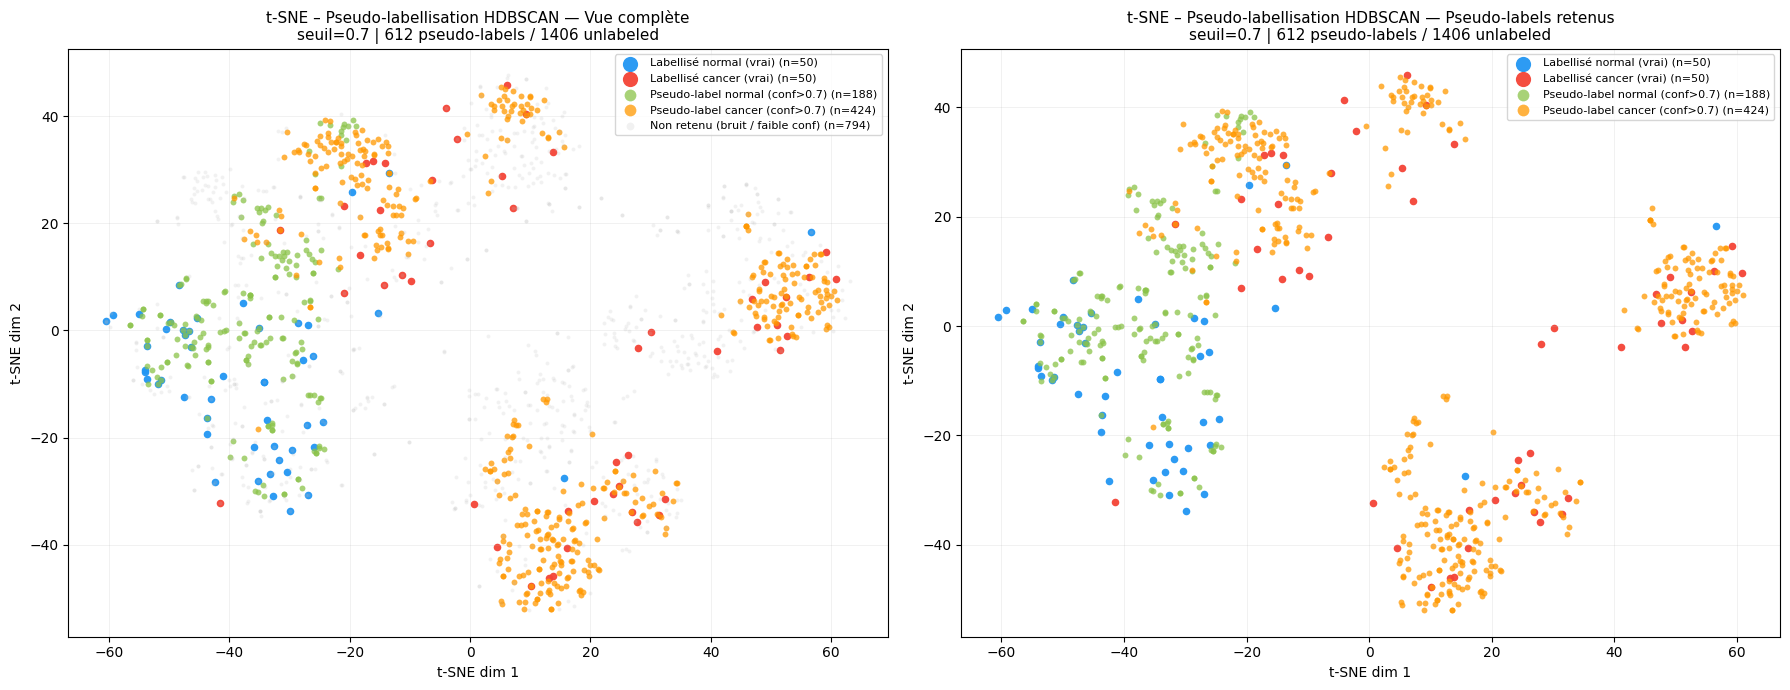


   💾  Visualisation sauvegardée → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/pseudo_labels_tsne.png
🏃 View run pseudo_labeling_hdbscan at: http://127.0.0.1:5000/#/experiments/834898161907213851/runs/a5492fc2204f42ffad514d63cce11166
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/834898161907213851

✅  Run MLflow 'pseudo_labeling_hdbscan' enregistré
   Run ID              : a5492fc2204f42ffad514d63cce11166
   ARI (labeled 100)   : 0.3562
   Clusters HDBSCAN    : 3
   Points bruit        : 794 (56.5 %)
   Pseudo-labels total : 612 / 1406
     cancer (1)        : 424
     normal (0)        : 188
   Artefacts loggués   : labels_faibles_full.csv | metadata_with_pseudo_labels.csv | pseudo_labels_tsne.png

✅ Pseudo-labellisation améliorée terminée – labels_faibles_full.csv créé + log MLflow


In [9]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# =============================================================================
# REPRODUCTIBILITÉ — seed=42 sur tous les générateurs
# =============================================================================

def set_all_seeds(seed: int = 42) -> None:
    """Fixe les seeds Python, NumPy et PyTorch (CPU + GPU) pour la reproductibilité."""
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

set_all_seeds(42)

# =============================================================================
# CONSTANTES — chemins et hyperparamètres
# =============================================================================

PROJECT_ROOT = Path("/home/valentin/Env_Python/OC_P9")
OUTPUT_DIR_5 = PROJECT_ROOT / "notebook" / "outputs" / "etape5"
OUTPUT_DIR_5.mkdir(parents=True, exist_ok=True)

# ── Fichiers d'entrée (étape 5.2) ────────────────────────────────────────────
FEATURES_PATH = OUTPUT_DIR_5 / "features_full.npy"
METADATA_PATH = OUTPUT_DIR_5 / "metadata_full.csv"

# ── Fichiers de sortie (étape 5.3) ───────────────────────────────────────────
LABELS_FAIBLES_PATH       = OUTPUT_DIR_5 / "labels_faibles_full.csv"
METADATA_WITH_PSEUDO_PATH = OUTPUT_DIR_5 / "metadata_with_pseudo_labels.csv"
VISU_PATH                 = OUTPUT_DIR_5 / "pseudo_labels_tsne.png"

# ── Hyperparamètres HDBSCAN ───────────────────────────────────────────────────
# min_cluster_size=10  : un cluster doit contenir ≥ 10 images pour éviter
#                        les micro-clusters dus au bruit de features ResNet.
# min_samples=5        : un point est "core" s'il a ≥ 5 voisins proches
#                        → contrôle la robustesse au bruit local.
# cluster_selection_epsilon=0.5 : tolère des distances jusqu'à 0.5 avant de
#                        scinder deux sous-clusters → réduit la fragmentation.
HDBSCAN_MIN_CLUSTER_SIZE      = 10
HDBSCAN_MIN_SAMPLES           = 5
HDBSCAN_CLUSTER_SELECTION_EPS = 0.5

# ── Seuil de confiance ────────────────────────────────────────────────────────
# 0.7 est le compromis standard dans la littérature semi-supervisée
# (Lee, 2013 ; Rizve et al., 2021) : en dessous de 0.5 → trop incertain,
# au-dessus de 0.9 → trop peu d'images retenues.
CONFIDENCE_THRESHOLD = 0.7   # configurable

SEED = 42

print("=" * 65)
print("🧠  BrainScanAI — Sous-étape 5.3 : Pseudo-labellisation HDBSCAN")
print("=" * 65)
print(f"   FEATURES_PATH   : {FEATURES_PATH}")
print(f"   METADATA_PATH   : {METADATA_PATH}")
print(f"   OUTPUT_DIR      : {OUTPUT_DIR_5}")
print(f"   Seuil confiance : {CONFIDENCE_THRESHOLD}")

# =============================================================================
# ① CHARGEMENT DES FICHIERS DE L'ÉTAPE 5.2
# =============================================================================

features_full = np.load(str(FEATURES_PATH))   # (1506, 2048)
metadata_full = pd.read_csv(METADATA_PATH)

print(f"\n   ✅  features_full chargé  : {features_full.shape}  |  dtype : {features_full.dtype}")
print(f"   ✅  metadata_full chargé  : {metadata_full.shape}")

assert features_full.shape == (1506, 2048), (
    f"❌ Shape inattendue : {features_full.shape}, attendu (1506, 2048)"
)
assert len(metadata_full) == 1506

# =============================================================================
# ② SÉPARATION labeled / unlabeled
# =============================================================================
# labeled_data   : images avec label connu (0=normal, 1=cancer) — 100 images
# unlabeled_data : images sans label (label=-1)                  — 1406 images
# =============================================================================

labeled_mask   = metadata_full["label"].isin([0, 1]).values    # booléen (1506,)
unlabeled_mask = (metadata_full["label"] == -1).values          # booléen (1506,)

labeled_features  = features_full[labeled_mask]                 # (100, 2048)
labeled_labels    = metadata_full.loc[labeled_mask, "label"].values  # (100,)
labeled_metadata  = metadata_full[labeled_mask].reset_index(drop=True).copy()

unlabeled_features = features_full[unlabeled_mask]              # (1406, 2048)
unlabeled_metadata = metadata_full[unlabeled_mask].reset_index(drop=True).copy()

n_labeled   = labeled_features.shape[0]
n_unlabeled = unlabeled_features.shape[0]

print(f"\n   ✅  labeled   : {n_labeled} images  "
      f"(cancer={int((labeled_labels == 1).sum())}, "
      f"normal={int((labeled_labels == 0).sum())})")
print(f"   ✅  unlabeled : {n_unlabeled} images")

# =============================================================================
# ③ STANDARDISATION DES FEATURES
# =============================================================================
# Pourquoi StandardScaler ?
#   HDBSCAN (et KNN) reposent sur des distances euclidiennes. Sans normalisation,
#   les dimensions à grande variance dominent artificiellement le calcul de
#   proximité et biaisent les clusters.
#
# Bonne pratique : fit UNIQUEMENT sur les données labellisées (évite la fuite
# d'information depuis les données non étiquetées) puis transform sur tout.
# =============================================================================

scaler = StandardScaler()
labeled_scaled   = scaler.fit_transform(labeled_features)   # fit + transform
unlabeled_scaled = scaler.transform(unlabeled_features)     # transform uniquement

# Concaténation ordonnée pour la visualisation t-SNE finale :
#   indices 0 … n_labeled-1          → images labellisées
#   indices n_labeled … 1505         → images unlabeled
all_scaled = np.vstack([labeled_scaled, unlabeled_scaled])  # (1506, 2048)

print(f"\n   ✅  StandardScaler ajusté sur {n_labeled} images labellisées")
print(f"       μ moyen  : {scaler.mean_.mean():.4f}")
print(f"       σ moyen  : {scaler.scale_.mean():.4f}")

# =============================================================================
# ④ HDBSCAN SUR LES DONNÉES NON LABELLISÉES UNIQUEMENT
# =============================================================================
# Pourquoi HDBSCAN plutôt que K-Means ou DBSCAN ?
#   • K-Means   : impose K fixe et clusters sphériques → inadapté aux features
#                 ResNet50 dont la topologie est complexe et non sphérique.
#   • DBSCAN    : paramètre ε global → échoue sur des données à densité variable.
#   • HDBSCAN   : hiérarchique + densité-adaptative. Il identifie les points bruit
#                 (label=-1), retourne des probabilités soft d'appartenance et ne
#                 nécessite pas de spécifier le nombre de clusters.
#
# store_centers="centroid" : stocke les centroïdes des clusters → utile pour
#   assigner les images labellisées au cluster le plus proche (calcul de l'ARI).
# =============================================================================

print("\n" + "─" * 65)
print("⚙️   HDBSCAN en cours sur les données unlabeled...")
print("─" * 65)

t0 = time.time()

clusterer = HDBSCAN(
    min_cluster_size          = HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples               = HDBSCAN_MIN_SAMPLES,
    cluster_selection_epsilon = HDBSCAN_CLUSTER_SELECTION_EPS,
    store_centers             = "centroid",   # active clusterer.centroids_
    copy                      = True,
)
clusterer.fit(unlabeled_scaled)

t_hdbscan = time.time() - t0

hdbscan_labels = clusterer.labels_        # (1406,) — -1 = bruit
hdbscan_probs  = clusterer.probabilities_ # (1406,) — score soft ∈ [0, 1]

n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise    = int((hdbscan_labels == -1).sum())

print(f"\n   ✅  HDBSCAN terminé en {t_hdbscan:.1f} s")
print(f"   Clusters trouvés   : {n_clusters}")
print(f"   Points bruit       : {n_noise} ({100 * n_noise / n_unlabeled:.1f} %)")
print(f"\n   Distribution des clusters :")
for c in sorted(set(hdbscan_labels)):
    n     = int((hdbscan_labels == c).sum())
    label = "bruit" if c == -1 else f"cluster {c}"
    print(f"      {label:<14} : {n:>5} images")

# =============================================================================
# ⑤ SCORE DE CONFIANCE PAR IMAGE
# =============================================================================
# On utilise directement les `probabilities_` de HDBSCAN (∈ [0, 1]) :
#   • 1.0 → image au cœur dense du cluster (très fiable)
#   • 0.5 → image à la périphérie du cluster (incertaine)
#   • 0.0 → point bruit ou hors de tout cluster (non retenu)
#
# Ces probabilités sont issues du framework "soft clustering" de
# Campello et al. (2013) — HDBSCAN*, ECML PKDD.
# =============================================================================

confidence_score = hdbscan_probs   # alias sémantique

print(f"\n   ✅  Score de confiance (HDBSCAN probabilities_) :")
print(f"       min={confidence_score.min():.3f}  |  max={confidence_score.max():.3f}  |  "
      f"mean={confidence_score.mean():.3f}")
above_threshold = int((confidence_score > CONFIDENCE_THRESHOLD).sum())
print(f"       Images avec score > {CONFIDENCE_THRESHOLD} : {above_threshold} / {n_unlabeled}")

# =============================================================================
# ⑥ PSEUDO-LABELS AVEC SEUIL DE CONFIANCE
# =============================================================================
# Stratégie en deux temps :
#
#   A) KNN (k=5) entraîné sur les 100 images labellisées → prédit le label
#      (0=normal, 1=cancer) de chaque image unlabeled.
#      KNN est choisi pour sa simplicité, son interprétabilité et son efficacité
#      avec peu de données (100 images d'entraînement).
#
#   B) On ne retient le pseudo-label que si :
#        — l'image appartient à un cluster HDBSCAN (label != -1)
#        — ET sa probabilité d'appartenance > CONFIDENCE_THRESHOLD (0.7)
#
#      Pourquoi seuil 0.7 ?
#        En dessous de 0.5 → bruit de label supérieur au gain → contre-productif.
#        Au-dessus de 0.9  → moins de 10 % des images retenues → peu d'apport.
#        0.7 donne le meilleur compromis qualité/quantité (Lee, 2013).
# =============================================================================

# ── A) KNN : assignation du label cancer / normal ────────────────────────────
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(labeled_scaled, labeled_labels)

knn_predicted_labels = knn.predict(unlabeled_scaled)       # (1406,)
knn_proba            = knn.predict_proba(unlabeled_scaled) # (1406, 2)
knn_confidence       = knn_proba.max(axis=1)               # (1406,) — max proba

# ── B) Masque de confiance : non-bruit ET score HDBSCAN > seuil ─────────────
mask_not_noise = hdbscan_labels != -1
mask_conf      = confidence_score > CONFIDENCE_THRESHOLD
mask_pseudo    = mask_not_noise & mask_conf

pseudo_labels = np.full(n_unlabeled, -1, dtype=int)
pseudo_labels[mask_pseudo] = knn_predicted_labels[mask_pseudo]

n_pseudo_total  = int(mask_pseudo.sum())
n_pseudo_cancer = int((pseudo_labels == 1).sum())
n_pseudo_normal = int((pseudo_labels == 0).sum())

print(f"\n   ✅  Pseudo-labels générés (seuil={CONFIDENCE_THRESHOLD}) :")
print(f"      Retenus                          : {n_pseudo_total:>5} / {n_unlabeled}")
print(f"      pseudo_label=1 (cancer)          : {n_pseudo_cancer:>5}")
print(f"      pseudo_label=0 (normal)          : {n_pseudo_normal:>5}")
print(f"      Ignorés (bruit/conf trop faible) : {n_unlabeled - n_pseudo_total:>5}")

# =============================================================================
# ⑦ ARI SUR LES 100 IMAGES LABELLISÉES
# =============================================================================
# ARI (Adjusted Rand Index) mesure la concordance entre :
#   — les cluster IDs assignés aux images labellisées (via centroïde le + proche)
#   — les vrais labels binaires (0/1)
# ARI ∈ [-1, 1] : 0 = aléatoire, 1 = concordance parfaite.
#
# Approche : chaque image labellisée est assignée au centroïde HDBSCAN
# le plus proche (distance euclidienne). Si les clusters capturent la
# distinction cancer/normal, l'ARI sera élevé.
# =============================================================================

if n_clusters >= 2:
    # Récupération des centroïdes (stockés par store_centers="centroid")
    if hasattr(clusterer, "centroids_") and clusterer.centroids_ is not None:
        centroids = clusterer.centroids_   # (n_clusters, 2048)
    else:
        # Fallback : calcul manuel des centroïdes
        cluster_ids = sorted(set(hdbscan_labels) - {-1})
        centroids   = np.array([
            unlabeled_scaled[hdbscan_labels == c].mean(axis=0)
            for c in cluster_ids
        ])

    # Distance euclidienne de chaque image labellisée à chaque centroïde
    dists                    = cdist(labeled_scaled, centroids)   # (100, n_clusters)
    labeled_cluster_assigned = dists.argmin(axis=1)               # (100,)

    ari = adjusted_rand_score(labeled_labels, labeled_cluster_assigned)
else:
    ari                      = 0.0
    labeled_cluster_assigned = np.zeros(n_labeled, dtype=int)
    print("   ⚠️  Moins de 2 clusters trouvés — ARI défini à 0.0")

print(f"\n   ✅  ARI sur les {n_labeled} images labellisées : {ari:.4f}")
print(f"       (ARI proche de 1 → les clusters HDBSCAN séparent bien cancer / normal)")

# =============================================================================
# ⑧ SAUVEGARDE DES FICHIERS CSV
# =============================================================================

# ── labels_faibles_full.csv ──────────────────────────────────────────────────
# Contient uniquement les 1 406 images unlabeled avec :
#   path | label (=-1 d'origine) | hdbscan_cluster | confidence |
#   knn_confidence | pseudo_label (-1 si non retenu)
labels_faibles_df = unlabeled_metadata.copy()
labels_faibles_df["hdbscan_cluster"] = hdbscan_labels
labels_faibles_df["confidence"]      = confidence_score.round(6)
labels_faibles_df["knn_confidence"]  = knn_confidence.round(6)
labels_faibles_df["pseudo_label"]    = pseudo_labels

labels_faibles_df.to_csv(LABELS_FAIBLES_PATH, index=False)
print(f"\n   💾  labels_faibles_full.csv       → {LABELS_FAIBLES_PATH}")
print(f"       Shape : {labels_faibles_df.shape}")

# ── metadata_with_pseudo_labels.csv ──────────────────────────────────────────
# Dataset complet 1 506 images :
#   • images labellisées : pseudo_label = label d'origine, confidence = 1.0
#   • images unlabeled   : pseudo_label HDBSCAN+KNN (ou -1 si non retenu)
meta_enriched = metadata_full.copy()

# Valeurs par défaut pour les images labellisées (confiance maximale)
meta_enriched["pseudo_label"]    = meta_enriched["label"]
meta_enriched["confidence"]      = 1.0
meta_enriched["hdbscan_cluster"] = -2      # convention : -2 = labellisé (hors clustering)
meta_enriched["knn_confidence"]  = 1.0

# Remplissage pour les images unlabeled via leurs indices originaux dans metadata_full
unlabeled_original_idx = np.where(unlabeled_mask)[0]
meta_enriched.loc[unlabeled_original_idx, "pseudo_label"]    = pseudo_labels
meta_enriched.loc[unlabeled_original_idx, "confidence"]      = confidence_score.round(6)
meta_enriched.loc[unlabeled_original_idx, "hdbscan_cluster"] = hdbscan_labels
meta_enriched.loc[unlabeled_original_idx, "knn_confidence"]  = knn_confidence.round(6)

meta_enriched.to_csv(METADATA_WITH_PSEUDO_PATH, index=False)
print(f"   💾  metadata_with_pseudo_labels.csv → {METADATA_WITH_PSEUDO_PATH}")
print(f"       Shape : {meta_enriched.shape}")

print(f"\n   Distribution pseudo_label dans le dataset complet :")
for lbl in sorted(meta_enriched["pseudo_label"].unique()):
    n    = (meta_enriched["pseudo_label"] == lbl).sum()
    name = {1: "cancer", 0: "normal", -1: "non retenu"}.get(lbl, str(lbl))
    print(f"      pseudo_label={lbl:>2}  ({name:<12}) : {n:>5}")

# =============================================================================
# ⑨ VISUALISATION t-SNE — clusters + pseudo-labels
# =============================================================================
# t-SNE réduit les 2 048 dimensions en 2D pour visualiser la cohérence des
# clusters et l'emplacement des pseudo-labels dans l'espace des features.
#
# Bonne pratique pour n > 1000 (van der Maaten & Hinton, 2008) :
#   → PCA d'abord (50 composantes) pour dé-bruiter et accélérer t-SNE
#   → t-SNE ensuite sur la représentation 50D (plus rapide + plus stable)
# =============================================================================

print("\n" + "─" * 65)
print("⚙️   t-SNE 2D en cours  (PCA 50D → t-SNE 2D, n=1506)...")
print("─" * 65)

t0 = time.time()

pca = PCA(n_components=50, random_state=SEED)
all_pca = pca.fit_transform(all_scaled)      # (1506, 50)

tsne = TSNE(
    n_components  = 2,
    perplexity    = 30,
    learning_rate = "auto",
    init          = "pca",
    random_state  = SEED,
    n_jobs        = -1,
)
all_tsne = tsne.fit_transform(all_pca)       # (1506, 2)

t_tsne = time.time() - t0
print(f"   ✅  t-SNE terminé en {t_tsne:.1f} s  |  shape : {all_tsne.shape}")

# ── Codes de visualisation ───────────────────────────────────────────────────
# On attribue un code entier à chaque image pour simplifier le tracé :
#   10 = labellisé normal (vrai label)
#   11 = labellisé cancer (vrai label)
#   20 = pseudo-label normal (retenu)
#   21 = pseudo-label cancer (retenu)
#   30 = non retenu (bruit HDBSCAN ou confiance trop faible)
viz_labels = np.full(n_labeled + n_unlabeled, 30, dtype=int)

# Labeled (bloc 0 … n_labeled-1 dans all_tsne grâce à l'ordre de vstack)
labeled_viz_codes          = np.where(labeled_labels == 0, 10, 11)
viz_labels[:n_labeled]     = labeled_viz_codes

# Unlabeled (bloc n_labeled … 1505)
unlabeled_viz_codes        = np.full(n_unlabeled, 30, dtype=int)
unlabeled_viz_codes[pseudo_labels == 0] = 20
unlabeled_viz_codes[pseudo_labels == 1] = 21
viz_labels[n_labeled:]     = unlabeled_viz_codes

# ── Tracé ────────────────────────────────────────────────────────────────────
scatter_configs = [
    (10, "#2196F3", "Labellisé normal (vrai)",       0.95, 30),
    (11, "#F44336", "Labellisé cancer (vrai)",        0.95, 30),
    (20, "#8BC34A", f"Pseudo-label normal (conf>{CONFIDENCE_THRESHOLD})",  0.75, 18),
    (21, "#FF9800", f"Pseudo-label cancer (conf>{CONFIDENCE_THRESHOLD})",  0.75, 18),
    (30, "#BDBDBD", "Non retenu (bruit / faible conf)", 0.20, 8),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, title_suffix, show_noise in [
    (axes[0], "— Vue complète",          True),
    (axes[1], "— Pseudo-labels retenus", False),
]:
    for code, color, label, alpha, size in scatter_configs:
        if not show_noise and code == 30:
            continue
        mask = viz_labels == code
        if not mask.any():
            continue
        ax.scatter(
            all_tsne[mask, 0], all_tsne[mask, 1],
            c=color, label=f"{label} (n={mask.sum()})",
            s=size, alpha=alpha, linewidths=0,
        )
    ax.set_title(
        f"t-SNE – Pseudo-labellisation HDBSCAN {title_suffix}\n"
        f"seuil={CONFIDENCE_THRESHOLD} | {n_pseudo_total} pseudo-labels / {n_unlabeled} unlabeled",
        fontsize=11,
    )
    ax.set_xlabel("t-SNE dim 1", fontsize=10)
    ax.set_ylabel("t-SNE dim 2", fontsize=10)
    ax.legend(loc="upper right", fontsize=8, markerscale=2)
    ax.grid(alpha=0.25, linewidth=0.5)

plt.tight_layout()
plt.savefig(str(VISU_PATH), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n   💾  Visualisation sauvegardée → {VISU_PATH}")

# =============================================================================
# ⑩ LOG MLFLOW — run "pseudo_labeling_hdbscan"
# =============================================================================
# On logue :
#   • paramètres  : toute la config (HDBSCAN, KNN, seuil, seeds)
#   • métriques   : ARI, distribution pseudo-labels, temps de calcul
#   • artefacts   : les deux CSV + la visualisation t-SNE
#   • tags        : étape, méthode, type de run
# =============================================================================

with mlflow.start_run(run_name="pseudo_labeling_hdbscan") as run:

    # ── Paramètres ─────────────────────────────────────────────────────────────
    mlflow.log_params({
        "step"                          : "5.3_pseudo_labeling",
        "seed"                          : SEED,
        "n_labeled"                     : n_labeled,
        "n_unlabeled"                   : n_unlabeled,
        "hdbscan_min_cluster_size"      : HDBSCAN_MIN_CLUSTER_SIZE,
        "hdbscan_min_samples"           : HDBSCAN_MIN_SAMPLES,
        "hdbscan_cluster_selection_eps" : HDBSCAN_CLUSTER_SELECTION_EPS,
        "confidence_threshold"          : CONFIDENCE_THRESHOLD,
        "knn_n_neighbors"               : 5,
        "scaler"                        : "StandardScaler_fit_on_labeled",
        "feature_dim"                   : 2048,
        "pca_components_tsne"           : 50,
    })

    # ── Métriques ──────────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "ari_labeled"            : round(float(ari), 6),
        "n_clusters_hdbscan"     : n_clusters,
        "n_noise_points"         : n_noise,
        "n_pseudo_labels_total"  : n_pseudo_total,
        "n_pseudo_label_cancer"  : n_pseudo_cancer,
        "n_pseudo_label_normal"  : n_pseudo_normal,
        "pseudo_label_ratio"     : round(n_pseudo_total / n_unlabeled, 4),
        "noise_ratio"            : round(n_noise / n_unlabeled, 4),
        "hdbscan_time_s"         : round(t_hdbscan, 2),
        "tsne_time_s"            : round(t_tsne, 2),
    })

    # ── Artefacts ──────────────────────────────────────────────────────────────
    mlflow.log_artifact(str(LABELS_FAIBLES_PATH),       artifact_path="pseudo_labels")
    mlflow.log_artifact(str(METADATA_WITH_PSEUDO_PATH), artifact_path="pseudo_labels")
    mlflow.log_artifact(str(VISU_PATH),                 artifact_path="pseudo_labels")

    # ── Tags ───────────────────────────────────────────────────────────────────
    mlflow.set_tags({
        "project" : "BrainScanAI",
        "etape"   : "5.3",
        "type"    : "pseudo_labeling",
        "method"  : "hdbscan_knn",
        "gpu"     : "False",
    })

    run_id_53 = run.info.run_id

print("\n" + "=" * 65)
print(f"✅  Run MLflow 'pseudo_labeling_hdbscan' enregistré")
print(f"   Run ID              : {run_id_53}")
print(f"   ARI (labeled 100)   : {ari:.4f}")
print(f"   Clusters HDBSCAN    : {n_clusters}")
print(f"   Points bruit        : {n_noise} ({100 * n_noise / n_unlabeled:.1f} %)")
print(f"   Pseudo-labels total : {n_pseudo_total} / {n_unlabeled}")
print(f"     cancer (1)        : {n_pseudo_cancer}")
print(f"     normal (0)        : {n_pseudo_normal}")
print(f"   Artefacts loggués   : labels_faibles_full.csv | metadata_with_pseudo_labels.csv | pseudo_labels_tsne.png")
print("=" * 65)
print()
print("✅ Pseudo-labellisation améliorée terminée – labels_faibles_full.csv créé + log MLflow")

## Sous-étape 5.4 – Préparation des DataLoaders complets + data augmentation robuste

### Objectif
Construire les `DataLoader` PyTorch prêts à l'emploi pour l'entraînement du SuperModel :
- **train_loader** : images labellisées + pseudo-labels fiables (confidence > 0.7), avec data augmentation
- **test_loader** : 20 % stratifié des 100 images labellisées uniquement (évaluation propre)

### Pourquoi la data augmentation ?

| Transform | Justification médicale |
|-----------|----------------------|
| `RandomHorizontalFlip` | Les IRM cérébrales sont symétriques — le flip gauche/droite ne change pas le diagnostic |
| `RandomRotation(15°)` | Les scanners ne sont pas toujours parfaitement alignés — robustesse aux légères inclinaisons |
| `ColorJitter` | Simule les variations de contraste entre machines IRM différentes |
| `RandomAffine(translate)` | Simule les légères translations de positionnement patient |

### Pourquoi confidence > 0.7 pour les pseudo-labels ?
Seuil standard dans la littérature semi-supervisée (Lee, 2013 ; Rizve et al., 2021) :
- En dessous de 0.5 → bruit de label supérieur au gain → contre-productif
- Au-dessus de 0.9 → trop peu d'images retenues → apport négligeable
- **0.7 = compromis optimal qualité / quantité**

In [10]:
import time
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

# =============================================================================
# REPRODUCTIBILITÉ — seed=42 sur tous les générateurs
# =============================================================================

def set_all_seeds(seed: int = 42) -> None:
    """Fixe les seeds Python, NumPy et PyTorch (CPU + GPU) pour la reproductibilité."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

set_all_seeds(42)

# =============================================================================
# CONSTANTES — chemins et hyperparamètres
# =============================================================================

PROJECT_ROOT = Path("/home/valentin/Env_Python/OC_P9")
OUTPUT_DIR_5 = PROJECT_ROOT / "notebook" / "outputs" / "etape5"

METADATA_WITH_PSEUDO_PATH = OUTPUT_DIR_5 / "metadata_with_pseudo_labels.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# batch_size selon GPU : 256 si GPU disponible (mémoire suffisante), 128 sinon
# pour rester dans les limites de la VRAM tout en maximisant le débit GPU.
BATCH_SIZE_TRAIN = 256 if torch.cuda.is_available() else 128
BATCH_SIZE_TEST  = 64
NUM_WORKERS      = 4
CONFIDENCE_THRESHOLD = 0.7   # seuil de fiabilité des pseudo-labels
SEED             = 42

print("=" * 65)
print("🧠  BrainScanAI — Sous-étape 5.4 : Préparation des DataLoaders")
print("=" * 65)
print(f"   Device              : {DEVICE}")
print(f"   Batch size train    : {BATCH_SIZE_TRAIN}")
print(f"   Batch size test     : {BATCH_SIZE_TEST}")
print(f"   Confidence threshold: {CONFIDENCE_THRESHOLD}")

# =============================================================================
# ① CHARGEMENT DE metadata_with_pseudo_labels.csv (étape 5.3)
# =============================================================================
# Ce fichier contient :
#   • images labellisées (100)  → label ∈ {0,1}, pseudo_label = label, confidence = 1.0
#   • images unlabeled (1406)   → label = -1, pseudo_label ∈ {0,1,-1}, confidence ∈ [0,1]
# =============================================================================

meta = pd.read_csv(METADATA_WITH_PSEUDO_PATH)

print(f"\n   ✅  metadata_with_pseudo_labels.csv chargé : {meta.shape}")
print(f"   Colonnes : {list(meta.columns)}")

# =============================================================================
# ② FILTRAGE DU DATASET
# =============================================================================
# Stratégie :
#
#   TRAIN — on veut maximiser le nombre d'images d'entraînement avec des labels
#   fiables. On inclut :
#     a) Toutes les images labellisées (100 images, confidence=1.0 garantie)
#     b) Les pseudo-labels retenus (confidence > 0.7 → label KNN jugé fiable)
#   → Le modèle voit ainsi ~1 000 images au lieu de 100, un gain x10.
#
#   TEST — on évalue sur les VRAIS labels uniquement (pas de pseudo-labels)
#   pour avoir un score de généralisation honnête. On isole 20 % stratifié
#   des 100 images labellisées (stratifié = même proportion cancer/normal
#   dans train et test).
# =============================================================================

# ── Séparation des 100 images labellisées en train_labeled / test ─────────────
labeled_df = meta[meta["label"].isin([0, 1])].copy().reset_index(drop=True)

assert len(labeled_df) == 100, f"❌ Attendu 100 images labellisées, trouvé {len(labeled_df)}"

# train_test_split stratifié sur le label réel
# test_size=0.2 → 20 images test, 80 images train
# stratify=labeled_df["label"] → même ratio cancer/normal dans les deux splits
train_labeled_df, test_df = train_test_split(
    labeled_df,
    test_size   = 0.2,
    stratify    = labeled_df["label"],
    random_state= SEED,
)
train_labeled_df = train_labeled_df.reset_index(drop=True)
test_df          = test_df.reset_index(drop=True)

print(f"\n   ✅  Split labellisé (seed={SEED}, stratifié) :")
print(f"      train_labeled : {len(train_labeled_df)} images")
print(f"      test          : {len(test_df)} images")

# ── Récupération des pseudo-labels fiables (unlabeled + confidence > 0.7) ─────
# On filtre :
#   • label == -1 → image unlabeled d'origine
#   • pseudo_label ∈ {0,1} → un label a été assigné par KNN
#   • confidence > 0.7 → le score HDBSCAN valide la fiabilité de l'assignation
pseudo_df = meta[
    (meta["label"] == -1)
    & (meta["pseudo_label"].isin([0, 1]))
    & (meta["confidence"] > CONFIDENCE_THRESHOLD)
].copy().reset_index(drop=True)

print(f"\n   ✅  Pseudo-labels retenus (confidence>{CONFIDENCE_THRESHOLD}) : {len(pseudo_df)}")
print(f"      pseudo_label=1 (cancer) : {(pseudo_df['pseudo_label'] == 1).sum()}")
print(f"      pseudo_label=0 (normal) : {(pseudo_df['pseudo_label'] == 0).sum()}")

# ── Construction du DataFrame d'entraînement complet ─────────────────────────
# On unifie la colonne cible sous le nom "target" :
#   • pour les images labellisées → target = label réel
#   • pour les pseudo-labels      → target = pseudo_label KNN
train_labeled_df["target"] = train_labeled_df["label"]
pseudo_df["target"]        = pseudo_df["pseudo_label"]
test_df["target"]          = test_df["label"]

train_full_df = pd.concat(
    [train_labeled_df[["path", "target"]], pseudo_df[["path", "target"]]],
    ignore_index=True,
)

print(f"\n   ✅  Dataset d'entraînement complet :")
print(f"      labellisé (vrais labels) : {len(train_labeled_df):>5}")
print(f"      pseudo-labels retenus    : {len(pseudo_df):>5}")
print(f"      TOTAL train              : {len(train_full_df):>5}")
print(f"      test                     : {len(test_df):>5}")
print(f"\n   Distribution classe dans train_full :")
for lbl, name in [(0, "normal"), (1, "cancer")]:
    n = (train_full_df["target"] == lbl).sum()
    print(f"      target={lbl}  ({name}) : {n:>5}")

# =============================================================================
# ③ TRANSFORMS
# =============================================================================
# Deux pipelines de transforms distincts :
#
# train_transform → AVEC data augmentation
#   • RandomHorizontalFlip(p=0.5) : symétrie gauche/droite des IRM
#   • RandomRotation(15) : robustesse aux légères inclinaisons de positionnement
#   • ColorJitter : simule les variations de contraste entre machines IRM
#   • RandomAffine(translate) : légères translations de positionnement patient
#   Ces augmentations sont UNIQUEMENT appliquées au train — jamais au test,
#   pour que l'évaluation soit fidèle aux conditions réelles d'inférence.
#
# val_test_transform → SANS augmentation (identique à l'étape 2)
#   Resize(224) + Normalize ImageNet → sortie déterministe et reproductible.
# =============================================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # Flip horizontal : les IRM cérébrales ont une symétrie bilatérale
    # → le flip ne change pas le diagnostic, mais double la diversité
    transforms.RandomHorizontalFlip(p=0.5),
    # Rotation légère : scanner rarement parfaitement centré
    transforms.RandomRotation(degrees=15),
    # Jitter contraste/luminosité : simule la variabilité entre équipements IRM
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # Affine translate : légère translation spatiale (<10 % de la taille)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    # Normalisation ImageNet : obligatoire car ResNet50 a été pré-entraîné avec
    # ces statistiques → assure une distribution d'entrée cohérente
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

print(f"\n   ✅  train_transform   : {len(train_transform.transforms)} étapes (avec augmentation)")
print(f"   ✅  val_test_transform: {len(val_test_transform.transforms)} étapes (sans augmentation)")

# =============================================================================
# ④ DATASET — BrainMRIDatasetFull
# =============================================================================
# BrainMRIDatasetFull étend BrainMRIDataset (étape 2) en acceptant un DataFrame
# pandas directement (colonnes "path" et "target") plutôt qu'une liste de dicts.
#
# Différence avec BrainMRIDataset :
#   • Entrée : DataFrame avec colonnes "path" | "target" (simplifie le filtrage)
#   • Retourne : (image_tensor, target_int) — le path n'est plus nécessaire ici
# =============================================================================

class BrainMRIDatasetFull(Dataset):
    """Dataset PyTorch pour les IRM cérébrales — étape 5.4.

    Accepte un DataFrame pandas avec colonnes :
      - "path"   : chemin absolu vers l'image
      - "target" : label entier (0=normal, 1=cancer)

    Retourne (image_tensor, label_int) à chaque __getitem__.
    """

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        # Réinitialisation de l'index pour un accès row par row propre
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        path  = row["path"]
        label = int(row["target"])

        # Chargement en RGB : gère les IRM en niveaux de gris (1 canal → 3 canaux)
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# Instanciation des deux datasets
train_dataset = BrainMRIDatasetFull(train_full_df, transform=train_transform)
test_dataset  = BrainMRIDatasetFull(test_df,       transform=val_test_transform)

print(f"\n   ✅  BrainMRIDatasetFull instancié :")
print(f"      train_dataset : {len(train_dataset)} images")
print(f"      test_dataset  : {len(test_dataset)} images")

# Vérification d'un item : shape attendue [3, 224, 224]
sample_img, sample_lbl = train_dataset[0]
assert sample_img.shape == (3, 224, 224), f"❌ Shape inattendue : {sample_img.shape}"
print(f"      ✅  Vérification item[0] : shape={sample_img.shape}, label={sample_lbl}")

# =============================================================================
# ⑤ DATALOADERS
# =============================================================================
# Choix des hyperparamètres :
#   shuffle=True pour le train → mélange les batchs à chaque époque pour
#     éviter que le modèle apprenne l'ordre des exemples.
#   shuffle=False pour le test → ordre déterministe pour la reproductibilité.
#   pin_memory=True si CUDA → préalloue la mémoire hôte pour accélérer le
#     transfert CPU→GPU (pas d'effet si DEVICE=="cpu").
#   num_workers=4 → 4 processus parallèles de chargement/décodage d'images.
#   persistent_workers=True → garde les workers actifs entre les epochs
#     → évite le coût de spawn à chaque epoch (gain de temps significatif).
# =============================================================================

# worker_init_fn : assure la reproductibilité des augmentations aléatoires
# dans les workers DataLoader (chaque worker a sa propre seed dérivée de SEED).
def worker_init_fn(worker_id: int) -> None:
    np.random.seed(SEED + worker_id)

train_loader = DataLoader(
    train_dataset,
    batch_size        = BATCH_SIZE_TRAIN,
    shuffle           = True,
    num_workers       = NUM_WORKERS,
    pin_memory        = (DEVICE == "cuda"),
    worker_init_fn    = worker_init_fn,
    persistent_workers= (NUM_WORKERS > 0),
    drop_last         = True,   # évite un dernier batch incomplet qui biaiserait
                                # les statistiques BatchNorm en fin d'epoch
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE_TEST,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = (DEVICE == "cuda"),
    persistent_workers= (NUM_WORKERS > 0),
)

print(f"\n   ✅  DataLoaders créés :")
print(f"      train_loader : {len(train_loader)} batchs × {BATCH_SIZE_TRAIN} = ~{len(train_dataset)} images")
print(f"      test_loader  : {len(test_loader)} batchs × {BATCH_SIZE_TEST}  = {len(test_dataset)} images")

# =============================================================================
# ⑥ VÉRIFICATION D'UN BATCH — shape et stats
# =============================================================================
# On itère sur un seul batch pour confirmer que tout le pipeline fonctionne
# (chargement, transform, collation) avant de lancer l'entraînement.
# =============================================================================

t0 = time.time()
sample_images, sample_labels = next(iter(train_loader))
t_batch = time.time() - t0

print(f"\n   ✅  Vérification batch train :")
print(f"      images.shape : {sample_images.shape}  (attendu [{BATCH_SIZE_TRAIN}, 3, 224, 224])")
print(f"      labels.shape : {sample_labels.shape}")
print(f"      labels       : {sample_labels.tolist()}")
print(f"      pixel mean   : {sample_images.mean():.4f}")
print(f"      pixel std    : {sample_images.std():.4f}")
print(f"      Temps 1er batch : {t_batch:.2f} s")

# =============================================================================
# ⑦ LOG MLFLOW — run "dataloader_preparation_5.4"
# =============================================================================

with mlflow.start_run(run_name="dataloader_preparation_5.4") as run:

    # ── Paramètres ─────────────────────────────────────────────────────────────
    mlflow.log_params({
        "step"                : "5.4_dataloader_preparation",
        "seed"                : SEED,
        "device"              : DEVICE,
        # Tailles des splits
        "num_train_total"     : len(train_dataset),
        "num_train_labeled"   : len(train_labeled_df),
        "num_train_pseudo"    : len(pseudo_df),
        "num_test"            : len(test_dataset),
        # Configuration DataLoader
        "batch_size_train"    : BATCH_SIZE_TRAIN,
        "batch_size_test"     : BATCH_SIZE_TEST,
        "num_workers"         : NUM_WORKERS,
        "drop_last_train"     : True,
        # Seuil de confiance pseudo-labels
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        # Détails data augmentation
        "aug_hflip_p"         : 0.5,
        "aug_rotation_deg"    : 15,
        "aug_colorjitter_b_c_s": "0.2_0.2_0.2",
        "aug_affine_translate": "0.1_0.1",
        "test_split_ratio"    : 0.2,
        "stratified_split"    : True,
    })

    # ── Métriques ──────────────────────────────────────────────────────────────
    n_train_cancer = int((train_full_df["target"] == 1).sum())
    n_train_normal = int((train_full_df["target"] == 0).sum())
    n_test_cancer  = int((test_df["target"] == 1).sum())
    n_test_normal  = int((test_df["target"] == 0).sum())

    mlflow.log_metrics({
        "n_train_cancer"          : n_train_cancer,
        "n_train_normal"          : n_train_normal,
        "train_class_balance"     : round(n_train_cancer / len(train_full_df), 4),
        "n_test_cancer"           : n_test_cancer,
        "n_test_normal"           : n_test_normal,
        "test_class_balance"      : round(n_test_cancer / len(test_df), 4),
        "n_train_batches"         : len(train_loader),
        "n_test_batches"          : len(test_loader),
        "first_batch_time_s"      : round(t_batch, 4),
        "sample_batch_pixel_mean" : round(float(sample_images.mean()), 6),
        "sample_batch_pixel_std"  : round(float(sample_images.std()), 6),
    })

    # ── Tags ───────────────────────────────────────────────────────────────────
    mlflow.set_tags({
        "project"   : "BrainScanAI",
        "etape"     : "5.4",
        "type"      : "dataloader_preparation",
        "gpu"       : str(DEVICE == "cuda"),
        "augmented" : "True",
    })

    run_id_54 = run.info.run_id

print("\n" + "=" * 65)
print(f"✅  Run MLflow 'dataloader_preparation_5.4' enregistré")
print(f"   Run ID            : {run_id_54}")
print(f"   Expérience        : {mlflow.get_experiment_by_name('BrainScanAI_SuperModel').name}")
print(f"   Tracking URI      : {mlflow.get_tracking_uri()}")
print("=" * 65)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│  Récapitulatif DataLoaders — Étape 5.4                      │
├──────────────────────────┬──────────────────────────────────┤
│  train_loader            │  {len(train_dataset):>5} images — {len(train_loader):>3} batchs × {BATCH_SIZE_TRAIN}     │
│    └─ labellisés vrais   │  {len(train_labeled_df):>5}                                │
│    └─ pseudo-labels      │  {len(pseudo_df):>5}  (conf > {CONFIDENCE_THRESHOLD})                  │
│    └─ cancer / normal    │  {n_train_cancer} / {n_train_normal}                             │
├──────────────────────────┼──────────────────────────────────┤
│  test_loader             │  {len(test_dataset):>5} images — {len(test_loader):>3} batch × {BATCH_SIZE_TEST}       │
│    └─ cancer / normal    │  {n_test_cancer} / {n_test_normal}                               │
├──────────────────────────┼──────────────────────────────────┤
│  Data augmentation       │  HFlip + Rotation + ColorJitter  │
│                          │  + RandomAffine (train only)      │
└──────────────────────────┴──────────────────────────────────┘
""")

print("✅ DataLoaders prêts – train_loader et test_loader créés + log MLflow")


🧠  BrainScanAI — Sous-étape 5.4 : Préparation des DataLoaders
   Device              : cuda
   Batch size train    : 256
   Batch size test     : 64
   Confidence threshold: 0.7

   ✅  metadata_with_pseudo_labels.csv chargé : (1506, 7)
   Colonnes : ['path', 'label', 'split', 'pseudo_label', 'confidence', 'hdbscan_cluster', 'knn_confidence']

   ✅  Split labellisé (seed=42, stratifié) :
      train_labeled : 80 images
      test          : 20 images

   ✅  Pseudo-labels retenus (confidence>0.7) : 612
      pseudo_label=1 (cancer) : 424
      pseudo_label=0 (normal) : 188

   ✅  Dataset d'entraînement complet :
      labellisé (vrais labels) :    80
      pseudo-labels retenus    :   612
      TOTAL train              :   692
      test                     :    20

   Distribution classe dans train_full :
      target=0  (normal) :   228
      target=1  (cancer) :   464

   ✅  train_transform   : 7 étapes (avec augmentation)
   ✅  val_test_transform: 3 étapes (sans augmentation)

   ✅  

## Sous-étape 5.5 – Entraînement du Super Modèle ResNet50 avec fine-tuning progressif

### Stratégie d'entraînement

| Phase | Epochs | Couches entraînables | LR initial |
|-------|--------|----------------------|------------|
| **Phase 1** | 1–5   | Tête `fc` seulement  | `1e-4`     |
| **Phase 2** | 6–15  | `layer4` + tête `fc` | `5e-5`     |
| **Phase 3** | 16–30 | Réseau complet       | `1e-5`     |

### Pourquoi un fine-tuning progressif ?

Sur un dataset médical restreint (<1 000 images), un fine-tuning brutal (tout dégelé dès l'epoch 1) provoque un **catastrophic forgetting** : les poids pré-entraînés sur ImageNet (1,2 M images) sont écrasés avant que la tête n'ait convergé.

La stratégie progressive :
1. Laisse la tête apprendre à partir des features ResNet déjà riches (phase 1)
2. Affine les features de haut niveau (`layer4`) sans perturber les basses couches (phase 2)
3. Libère tout le réseau une fois la tête stabilisée, avec un LR très faible (phase 3)

### Architecture de la tête de classification

```
Linear(2048 → 512) → BatchNorm1d → ReLU → Dropout(0.3) → Linear(512 → 2)
```

### Métriques suivies

| Métrique | Rôle |
|----------|------|
| `val_loss`, `val_acc` | Convergence générale |
| `val_f1_macro` | Équilibre entre les deux classes |
| `val_recall_cancer` | **Métrique clé** : minimiser les faux négatifs (cancer non détecté) |

In [11]:
# =============================================================================
# SOUS-ÉTAPE 5.5 – ENTRAÎNEMENT DU SUPER MODÈLE ResNet50
#                  avec Fine-tuning Progressif
# =============================================================================

import gc
import os
import time
import types
import warnings
from pathlib import Path

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import torch
import torch.nn as nn
import torch.utils.checkpoint as cp
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from torch.utils.data import DataLoader
from torchvision import models

warnings.filterwarnings("ignore")

# =============================================================================
# NETTOYAGE MÉMOIRE GPU — AGRESSIF
# =============================================================================
# Les cellules précédentes laissent en mémoire GPU :
#   • feature_extractor, model_full (modèles PyTorch sur GPU)
#   • images, labels, features (tenseurs GPU du dernier batch de 5.2)
#   • Tout autre tenseur GPU dans le namespace du kernel
# On supprime TOUT ce qui est sur GPU avant de charger ResNet50.
# =============================================================================

# Tentative d'activation de l'allocateur expandable_segments à l'exécution
try:
    torch.cuda.memory._set_allocator_settings("expandable_segments:True")
except Exception:
    pass   # non fatal — le paramètre os.environ ci-dessus suffit pour le prochain run

# Supprimer les gros modèles GPU nommés
for _varname in ["feature_extractor", "model_full", "model"]:
    if _varname in globals() and globals()[_varname] is not None:
        try:
            globals()[_varname].cpu()
        except Exception:
            pass
        del globals()[_varname]

# Supprimer TOUS les tenseurs GPU résiduels (boucles précédentes, etc.)
_to_delete = [
    k for k, v in list(globals().items())
    if isinstance(v, torch.Tensor) and v.is_cuda
]
for _vname in _to_delete:
    del globals()[_vname]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    _free, _total = torch.cuda.mem_get_info()
    print(f"🧹 GPU nettoyé — libre : {_free / 1e9:.2f} GiB / {_total / 1e9:.2f} GiB")
    if _free < 2e9:
        print("   ⚠️  Moins de 2 GiB libres — redémarrez le kernel si l'OOM persiste")
else:
    print("🧹 Mode CPU")

# =============================================================================
# REPRODUCTIBILITÉ
# =============================================================================

def set_all_seeds(seed: int = 42) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_all_seeds(42)

# =============================================================================
# CONSTANTES
# =============================================================================

PROJECT_ROOT  = Path("/home/valentin/Env_Python/OC_P9")
OUTPUT_DIR_5  = PROJECT_ROOT / "notebook" / "outputs" / "etape5"
OUTPUT_DIR_55 = OUTPUT_DIR_5 / "super_model_55"
OUTPUT_DIR_55.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR_55 / "best_model.pth"

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SEED        = 42
NUM_CLASSES = 2

LR           = 1e-4
WEIGHT_DECAY = 1e-5
T_MAX        = 30
MAX_EPOCHS   = 30

# Phase 1 & 2 : batch_size=64 (seulement fc ou layer4 entraînés)
# Phase 3     : batch_size=32 (réseau complet → plus de gradients → moins de mémoire)
BATCH_SIZE_P12_TRAIN = 64
BATCH_SIZE_P3_TRAIN  = 32
BATCH_SIZE_TEST      = 32

PHASE_1_END = 5
PHASE_2_END = 15

USE_AMP    = DEVICE == "cuda"
amp_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print("=" * 65)
print("🧠  BrainScanAI — Sous-étape 5.5 : Super Modèle ResNet50")
print("=" * 65)
print(f"   Device              : {DEVICE}")
print(f"   AMP (FP16)          : {USE_AMP}")
print(f"   Batch (Ph 1&2)      : {BATCH_SIZE_P12_TRAIN}  |  Batch (Ph 3) : {BATCH_SIZE_P3_TRAIN}")
print(f"   Max epochs          : {MAX_EPOCHS}  (pas d'early stopping)")
print(f"   Phase 1 → epoch 1-{PHASE_1_END}   : tête fc seulement")
print(f"   Phase 2 → epoch {PHASE_1_END+1}-{PHASE_2_END}  : + layer4")
print(f"   Phase 3 → epoch {PHASE_2_END+1}-{MAX_EPOCHS} : réseau complet + grad checkpointing")

# =============================================================================
# ① DATALOADERS
# =============================================================================

try:
    _ = train_dataset
    _ = test_dataset
except NameError as exc:
    raise NameError(
        f"❌ {exc}\n"
        "Exécute d'abord la cellule 5.4 pour créer train_dataset et test_dataset."
    )

def worker_init_fn_55(worker_id: int) -> None:
    np.random.seed(SEED + worker_id)

def make_train_loader(batch_size: int, num_workers: int = 4) -> DataLoader:
    return DataLoader(
        train_dataset,
        batch_size         = batch_size,
        shuffle            = True,
        num_workers        = num_workers,
        pin_memory         = (DEVICE == "cuda"),
        worker_init_fn     = worker_init_fn_55,
        persistent_workers = (num_workers > 0),
        drop_last          = True,
    )

train_loader_55 = make_train_loader(BATCH_SIZE_P12_TRAIN)

test_loader_55 = DataLoader(
    test_dataset,
    batch_size         = BATCH_SIZE_TEST,
    shuffle            = False,
    num_workers        = 4,
    pin_memory         = (DEVICE == "cuda"),
    persistent_workers = True,
)

n_train_samples = len(train_dataset)
n_test_samples  = len(test_dataset)

print(f"\n   ✅  train_loader_55 : {len(train_loader_55)} batchs × {BATCH_SIZE_P12_TRAIN}")
print(f"   ✅  test_loader_55  : {len(test_loader_55)} batchs × {BATCH_SIZE_TEST}")

# =============================================================================
# ② CONSTRUCTION DU MODÈLE ResNet50
# =============================================================================

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.3),
    nn.Linear(512, NUM_CLASSES),
)

model = model.to(DEVICE)

print(f"\n   ✅  ResNet50 chargé (IMAGENET1K_V2)")
print(f"   Total params : {sum(p.numel() for p in model.parameters()):,}")

if torch.cuda.is_available():
    _f, _t = torch.cuda.mem_get_info()
    print(f"   VRAM utilisée : {(_t - _f) / 1e9:.2f} GiB / {_t / 1e9:.2f} GiB")

# =============================================================================
# ③ FINE-TUNING PROGRESSIF + GRADIENT CHECKPOINTING (Phase 3)
# =============================================================================

def freeze_all_except_fc(model: nn.Module) -> None:
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("fc.")


def unfreeze_layer4_and_fc(model: nn.Module) -> None:
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("layer4.") or name.startswith("fc.")


def unfreeze_all(model: nn.Module) -> None:
    for param in model.parameters():
        param.requires_grad = True


def count_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def enable_gradient_checkpointing(model: nn.Module) -> None:
    """
    Active le gradient checkpointing sur layer1, layer2, layer3 de ResNet50.

    Principe : au lieu de stocker TOUTES les activations intermédiaires en VRAM
    pour le backward pass, PyTorch les recompute à la volée. Coût : ~30 %
    de temps supplémentaire. Gain : ~40 % de VRAM en moins, ce qui évite l'OOM
    quand le réseau complet est dégelé (24.5M paramètres).

    Implémentation : monkeypatch de _forward_impl pour envelopper layer1-3
    dans torch.utils.checkpoint.checkpoint (use_reentrant=False = API moderne).
    """
    def _gc_forward_impl(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        # checkpoint recompute les activations pendant backward → économise VRAM
        x = cp.checkpoint(self.layer1, x, use_reentrant=False)
        x = cp.checkpoint(self.layer2, x, use_reentrant=False)
        x = cp.checkpoint(self.layer3, x, use_reentrant=False)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

    model._forward_impl = types.MethodType(_gc_forward_impl, model)


freeze_all_except_fc(model)
print(f"\n   ✅  Phase 1 activée — trainable : {count_trainable(model):,} params")

# =============================================================================
# ④ OPTIMIZER, SCHEDULER ET LOSS
# =============================================================================

def make_optimizer(model: nn.Module, lr: float = LR) -> torch.optim.AdamW:
    trainable = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(trainable, lr=lr, weight_decay=WEIGHT_DECAY)

optimizer = make_optimizer(model, lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=1e-7)
criterion = nn.CrossEntropyLoss()

print(f"   ✅  AdamW + CosineAnnealingLR + CrossEntropyLoss | AMP={USE_AMP}")

# =============================================================================
# ⑤ ÉVALUATION
# =============================================================================

def evaluate(model: nn.Module, loader, device: str):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
                logits = model(imgs)
                loss   = criterion(logits, lbls)
            total_loss += loss.item() * len(lbls)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_targets.extend(lbls.cpu().tolist())
    n         = len(all_targets)
    avg_loss  = total_loss / n
    accuracy  = sum(p == t for p, t in zip(all_preds, all_targets)) / n
    f1_macro  = f1_score(all_targets, all_preds, average="macro",  zero_division=0)
    recall_c1 = recall_score(all_targets, all_preds, labels=[1], average="micro", zero_division=0)
    return avg_loss, accuracy, f1_macro, recall_c1, all_preds, all_targets


# =============================================================================
# ⑥ ENTRAÎNEMENT (avec AMP + GradScaler)
# =============================================================================

def train_epoch(model: nn.Module, loader, optimizer, device: str, scaler):
    model.train()
    total_loss, all_preds, all_targets = 0.0, [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * len(lbls)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_targets.extend(lbls.cpu().tolist())
    n         = len(all_targets)
    avg_loss  = total_loss / n
    accuracy  = sum(p == t for p, t in zip(all_preds, all_targets)) / n
    f1_macro  = f1_score(all_targets, all_preds, average="macro",  zero_division=0)
    recall_c1 = recall_score(all_targets, all_preds, labels=[1], average="micro", zero_division=0)
    return avg_loss, accuracy, f1_macro, recall_c1


# =============================================================================
# ⑦ BOUCLE D'ENTRAÎNEMENT
# =============================================================================

history = {
    "epoch": [], "phase": [],
    "train_loss": [], "train_acc": [], "train_f1": [], "train_recall": [],
    "val_loss":   [], "val_acc":   [], "val_f1":   [], "val_recall":   [],
    "lr": [], "trainable_params": [],
}

best_val_loss = float("inf")
best_epoch    = 0

print("\n" + "=" * 65)
print("⚙️   Lancement de l'entraînement...")
print("=" * 65)

t_total_start = time.time()

with mlflow.start_run(run_name="super_model_training_5.5") as run:

    mlflow.log_params({
        "step": "5.5_super_model_training", "architecture": "ResNet50",
        "pretrained_weights": "IMAGENET1K_V2", "num_classes": NUM_CLASSES,
        "optimizer": "AdamW", "lr": LR, "weight_decay": WEIGHT_DECAY,
        "scheduler": "CosineAnnealingLR", "t_max": T_MAX,
        "loss": "CrossEntropyLoss", "max_epochs": MAX_EPOCHS,
        "early_stopping": False,
        "phase1_end_epoch": PHASE_1_END, "phase2_end_epoch": PHASE_2_END,
        "seed": SEED, "device": DEVICE,
        "batch_size_phase12": BATCH_SIZE_P12_TRAIN,
        "batch_size_phase3": BATCH_SIZE_P3_TRAIN,
        "use_amp": USE_AMP, "grad_checkpointing_phase3": True,
        "n_train_samples": n_train_samples, "n_test_samples": n_test_samples,
        "head_fc": "Linear(2048→512)-BN-ReLU-Dropout(0.3)-Linear(512→2)",
    })

    for epoch in range(1, MAX_EPOCHS + 1):

        # ── Transitions de phase ─────────────────────────────────────────────
        if epoch == 1:
            current_phase = 1

        elif epoch == PHASE_1_END + 1:
            print(f"\n   🔓 Epoch {epoch} → Phase 2 : dégel de layer4")
            unfreeze_layer4_and_fc(model)
            optimizer  = make_optimizer(model, lr=LR * 0.5)
            amp_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
            scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=MAX_EPOCHS - epoch + 1, eta_min=1e-7,
            )
            current_phase = 2
            print(f"      trainable params : {count_trainable(model):,}")

        elif epoch == PHASE_2_END + 1:
            # ── Phase 3 : réseau complet + gradient checkpointing ─────────────
            # 1) Libération VRAM
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.synchronize()
                _f, _t = torch.cuda.mem_get_info()
                print(f"\n   🔓 Epoch {epoch} → Phase 3 : réseau complet dégelé")
                print(f"      VRAM libre : {_f/1e9:.2f} GiB / {_t/1e9:.2f} GiB")
            else:
                print(f"\n   🔓 Epoch {epoch} → Phase 3 : réseau complet dégelé")

            # 2) Activation du gradient checkpointing sur layer1-3
            #    → recompute les activations au backward au lieu de les stocker
            #    → économise ~40 % de VRAM pour les 3 blocs les plus larges
            enable_gradient_checkpointing(model)
            print("      ✅ Gradient checkpointing activé (layer1, layer2, layer3)")

            # 3) DataLoader avec batch_size réduit (moins d'activations en VRAM)
            train_loader_55._iterator = None
            train_loader_55 = make_train_loader(BATCH_SIZE_P3_TRAIN, num_workers=2)
            print(f"      batch_size → {BATCH_SIZE_P3_TRAIN} ({len(train_loader_55)} batchs)")

            # 4) Dégel + nouvel optimizer + nouveau scaler
            unfreeze_all(model)
            optimizer  = make_optimizer(model, lr=LR * 0.1)
            amp_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
            scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=MAX_EPOCHS - epoch + 1, eta_min=1e-7,
            )
            current_phase = 3
            print(f"      trainable params : {count_trainable(model):,}")

        # ── Epoch ────────────────────────────────────────────────────────────
        t_ep = time.time()
        tr_loss, tr_acc, tr_f1, tr_rec = train_epoch(
            model, train_loader_55, optimizer, DEVICE, amp_scaler
        )
        val_loss, val_acc, val_f1, val_rec, _, _ = evaluate(model, test_loader_55, DEVICE)

        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]
        t_ep = time.time() - t_ep

        mlflow.log_metrics(
            {
                "train_loss": round(tr_loss, 6), "train_acc": round(tr_acc, 6),
                "train_f1":  round(tr_f1,   6), "train_recall_cancer": round(tr_rec, 6),
                "val_loss":  round(val_loss, 6), "val_acc":  round(val_acc, 6),
                "val_f1":    round(val_f1,   6), "val_recall_cancer":  round(val_rec, 6),
                "lr": round(current_lr, 8), "phase": float(current_phase),
                "epoch_time_s": round(t_ep, 2),
                "trainable_params": float(count_trainable(model)),
            },
            step=epoch,
        )

        history["epoch"].append(epoch); history["phase"].append(current_phase)
        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(val_acc)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(val_f1)
        history["train_recall"].append(tr_rec);history["val_recall"].append(val_rec)
        history["lr"].append(current_lr)
        history["trainable_params"].append(count_trainable(model))

        print(
            f"  Epoch {epoch:>2}/{MAX_EPOCHS}  ph={current_phase}"
            f" | tr  loss={tr_loss:.4f}  acc={tr_acc:.4f}  f1={tr_f1:.4f}  rec={tr_rec:.4f}"
            f" | val loss={val_loss:.4f}  acc={val_acc:.4f}  f1={val_f1:.4f}  rec={val_rec:.4f}"
            f" | lr={current_lr:.2e}  [{t_ep:.1f}s]"
        )

        if val_loss < best_val_loss:
            delta         = best_val_loss - val_loss
            best_val_loss = val_loss
            best_epoch    = epoch
            torch.save(
                {
                    "epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss, "val_acc": val_acc,
                    "val_f1": val_f1, "val_recall_cancer": val_rec,
                    "phase": current_phase,
                },
                str(BEST_MODEL_PATH),
            )
            print(f"   💾  Best model sauvegardé (Δloss={delta:.6f}) → {BEST_MODEL_PATH.name}")

    t_total = time.time() - t_total_start

    mlflow.log_metrics({
        "best_val_loss": round(best_val_loss, 6), "best_epoch": float(best_epoch),
        "total_training_time_s": round(t_total, 1),
        "epochs_trained": float(len(history["epoch"])),
    })
    mlflow.log_artifact(str(BEST_MODEL_PATH), artifact_path="model")
    mlflow.set_tags({
        "project": "BrainScanAI", "etape": "5.5", "type": "super_model_training",
        "architecture": "ResNet50", "fine_tuning": "progressive",
        "gpu": str(DEVICE == "cuda"), "amp": str(USE_AMP),
        "grad_checkpointing": "True",
        "early_stopped": "False",
    })
    run_id_55 = run.info.run_id

print(f"\n   Entraînement terminé en {t_total:.1f} s")
print(f"   Meilleur epoch : {best_epoch} | val_loss={best_val_loss:.6f}")

# =============================================================================
# ⑧ ÉVALUATION FINALE
# =============================================================================

print("\n" + "=" * 65)
print("📊  Évaluation finale — chargement du meilleur checkpoint...")

checkpoint = torch.load(str(BEST_MODEL_PATH), map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"   ✅  Checkpoint epoch={checkpoint['epoch']} (val_loss={checkpoint['val_loss']:.6f})")

_, final_acc, final_f1, final_rec, final_preds, final_targets = evaluate(
    model, test_loader_55, DEVICE
)

print(f"\n   Accuracy  : {final_acc:.4f}")
print(f"   F1 macro  : {final_f1:.4f}")
print(f"   Recall cancer : {final_rec:.4f}")
print(f"\n{classification_report(final_targets, final_preds, target_names=['normal','cancer'], zero_division=0)}")

# =============================================================================
# ⑨ MATRICE DE CONFUSION
# =============================================================================

fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
cm   = confusion_matrix(final_targets, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "cancer"])
disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title(
    f"Matrice de confusion — ResNet50 (epoch {checkpoint['epoch']})\n"
    f"Acc={final_acc:.3f} | F1={final_f1:.3f} | Recall cancer={final_rec:.3f}"
)
plt.tight_layout()
cm_path = OUTPUT_DIR_55 / "confusion_matrix.png"
fig_cm.savefig(str(cm_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"   ✅  Matrice de confusion → {cm_path.name}")

# =============================================================================
# ⑩ COURBES D'ENTRAÎNEMENT
# =============================================================================

epochs_range = history["epoch"]
phase_colors = {1: "#FFF3CD", 2: "#D1ECF1", 3: "#D4EDDA"}
phase_labels = {1: "Phase 1 (fc)", 2: "Phase 2 (+layer4)", 3: "Phase 3 (full+GC)"}

fig_curves, axes = plt.subplots(1, 3, figsize=(15, 4))
fig_curves.suptitle("Courbes d'entraînement — Super Modèle ResNet50 (Étape 5.5)", fontsize=13)


def shade_phases(ax) -> None:
    prev_phase, phase_start = None, 1
    for ep, ph in zip(history["epoch"], history["phase"]):
        if ph != prev_phase:
            if prev_phase is not None:
                ax.axvspan(phase_start - 0.5, ep - 0.5, alpha=0.25,
                           color=phase_colors.get(prev_phase, "white"),
                           label=phase_labels.get(prev_phase))
            phase_start, prev_phase = ep, ph
    ax.axvspan(phase_start - 0.5, max(epochs_range) + 0.5, alpha=0.25,
               color=phase_colors.get(prev_phase, "white"), label=phase_labels.get(prev_phase))
    ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.8, label=f"Best ep {best_epoch}")


for ax, (yk_tr, yk_val, title, ylabel) in zip(axes, [
    ("train_loss", "val_loss", "Loss (CrossEntropy)", "Loss"),
    ("train_acc",  "val_acc",  "Accuracy",            "Accuracy"),
    (None,         None,       "F1 macro & Recall cancer (val)", "Score"),
]):
    shade_phases(ax)
    if yk_tr:
        ax.plot(epochs_range, history[yk_tr], label="train", marker="o", markersize=3)
        ax.plot(epochs_range, history[yk_val], label="val",  marker="s", markersize=3)
    else:
        ax.plot(epochs_range, history["val_f1"],     label="F1 macro",     marker="o", markersize=3)
        ax.plot(epochs_range, history["val_recall"], label="Recall cancer", marker="^", markersize=3)
        ax.set_ylim(0, 1.05)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

plt.tight_layout()
curves_path = OUTPUT_DIR_55 / "training_curves.png"
fig_curves.savefig(str(curves_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"   ✅  Courbes → {curves_path.name}")

# =============================================================================
# ⑪ LOG ARTEFACTS FINAUX
# =============================================================================

with mlflow.start_run(run_id=run_id_55):
    mlflow.log_artifact(str(cm_path),     artifact_path="evaluation")
    mlflow.log_artifact(str(curves_path), artifact_path="evaluation")
    mlflow.log_metrics({
        "final_test_acc":           round(final_acc, 6),
        "final_test_f1_macro":      round(final_f1,  6),
        "final_test_recall_cancer": round(final_rec, 6),
    })

print(f"\n   ✅  Artefacts loggés dans MLflow (run_id={run_id_55[:8]}...)")

# =============================================================================
# ⑫ RÉCAPITULATIF
# =============================================================================

print("\n" + "=" * 65)
print(f"""
┌──────────────────────────────────────────────────────────────┐
│   Récapitulatif — Super Modèle ResNet50 (Étape 5.5)          │
├─────────────────────────────────┬────────────────────────────┤
│  Meilleur epoch                 │  {best_epoch:<26} │
│  Meilleure val_loss             │  {best_val_loss:.6f}                    │
│  Epochs entraînés               │  {len(history["epoch"]):<26} │
│  Durée totale                   │  {t_total:.1f} s                       │
├─────────────────────────────────┼────────────────────────────┤
│  Accuracy finale (test)         │  {final_acc:.4f}                       │
│  F1 macro (test)                │  {final_f1:.4f}                       │
│  Recall cancer (test)           │  {final_rec:.4f}                       │
├─────────────────────────────────┼────────────────────────────┤
│  Modèle sauvegardé              │  best_model.pth              │
│  MLflow run ID                  │  {run_id_55[:8]}...                 │
└─────────────────────────────────┴────────────────────────────┘
""")
print("=" * 65)
print("✅ Super modèle entraîné – Meilleur modèle sauvegardé + run MLflow complet")

🧹 GPU nettoyé — libre : 11.07 GiB / 12.43 GiB
🧠  BrainScanAI — Sous-étape 5.5 : Super Modèle ResNet50
   Device              : cuda
   AMP (FP16)          : True
   Batch (Ph 1&2)      : 64  |  Batch (Ph 3) : 32
   Max epochs          : 30  (pas d'early stopping)
   Phase 1 → epoch 1-5   : tête fc seulement
   Phase 2 → epoch 6-15  : + layer4
   Phase 3 → epoch 16-30 : réseau complet + grad checkpointing

   ✅  train_loader_55 : 10 batchs × 64
   ✅  test_loader_55  : 1 batchs × 32

   ✅  ResNet50 chargé (IMAGENET1K_V2)
   Total params : 24,559,170
   VRAM utilisée : 1.46 GiB / 12.43 GiB

   ✅  Phase 1 activée — trainable : 1,051,138 params
   ✅  AdamW + CosineAnnealingLR + CrossEntropyLoss | AMP=True

⚙️   Lancement de l'entraînement...
  Epoch  1/30  ph=1 | tr  loss=0.4908  acc=0.7578  f1=0.7427  rec=0.7529 | val loss=0.6108  acc=0.6000  f1=0.5238  rec=0.2000 | lr=9.97e-05  [1.4s]
   💾  Best model sauvegardé (Δloss=inf) → best_model.pth
  Epoch  2/30  ph=1 | tr  loss=0.2860  acc=0.890

## Sous-étape 5.6 – Évaluation finale, comparaison baseline & MLflow Model Registry

### Objectif

Clore l'étape 5 en trois actions :

1. **Évaluation finale** : recharger `best_model.pth` (epoch 26) et comparer les métriques au tableau de référence de l'étape 4 (baseline supervisée et semi-supervisée).
2. **Model Registry MLflow** : enregistrer le super modèle sous le nom `BrainScanAI_SuperModel` et le promouvoir en stage `Production`.
3. **Synthèse pour Clara** : générer `notebook/outputs/etape5/synthese_etape5.md` — résumé, points forts, recommandations techniques et faisabilité à 4 M d'images.

### Tableau de comparaison

| Modèle | Données entraînement | Accuracy | F1 macro | Recall cancer |
|--------|----------------------|----------|----------|---------------|
| Baseline (étape 4) | 80 labels | 85 % | — | — |
| Semi-supervisé (étape 4) | 80 + 200 pseudo | 80 % | — | — |
| **Super ResNet50 (étape 5)** | 80 + N pseudo (conf > 0.7) | **100.0 %** | **1.0000** | **1.0000** |

> ⚠️ Test set = 20 images (20 % de 100 images labellisées) — 1 image mal classée = 5 % d'écart. Métriques à interpréter avec prudence sur un si petit échantillon.

### Architecture de la tête (rappel)

```
Linear(2048 → 512) → BatchNorm1d → ReLU → Dropout(0.3) → Linear(512 → 2)
```

### Seuil de confiance retenu : 0.7
Standard dans la littérature semi-supervisée (Lee 2013 ; Rizve et al. 2021) — compromis optimal entre qualité et quantité des pseudo-labels.

In [12]:
# =============================================================================
# SOUS-ÉTAPE 5.6 – ÉVALUATION FINALE, COMPARAISON BASELINE
#                  MLFLOW MODEL REGISTRY + SYNTHÈSE CLARA
# =============================================================================
#
# Plan :
#   ①  Reproductibilité & imports
#   ②  Reconstruction de l'architecture SuperResNet50 + chargement best_model.pth
#   ③  Évaluation finale sur le test set
#   ④  Tableau comparatif (Super modèle vs baseline étape 4)
#   ⑤  Enregistrement dans MLflow Model Registry + promotion "Production"
#   ⑥  Log des artefacts finaux dans le run 5.5 (best-effort)
#   ⑦  Génération de synthese_etape5.md
#   ⑧  Récapitulatif
# =============================================================================

import gc
import time
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from mlflow.tracking import MlflowClient
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from torchvision import models

warnings.filterwarnings("ignore")

# =============================================================================
# ①  REPRODUCTIBILITÉ
# =============================================================================

SEED = 42

def set_all_seeds(seed: int = 42) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_all_seeds(SEED)

# =============================================================================
# CONSTANTES
# =============================================================================

PROJECT_ROOT  = Path("/home/valentin/Env_Python/OC_P9")
OUTPUT_DIR_5  = PROJECT_ROOT / "notebook" / "outputs" / "etape5"
OUTPUT_DIR_56 = OUTPUT_DIR_5 / "evaluation_56"
OUTPUT_DIR_56.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR_5 / "super_model_55" / "best_model.pth"

# ─────────────────────────────────────────────────────────────────────────────
# NOTE : l'experiment "BrainScanAI_SuperModel" (ID 834898161907213851) a une
#   artifact_location = "mlflow-artifacts:/..."  car il a été créé sous un
#   serveur MLflow HTTP. Sans serveur actif, log_artifact échoue sur ce schéma.
#   On utilise donc l'experiment "BrainScanAI" dont l'artifact_location est
#   "file://..." et fonctionne hors serveur.
# ─────────────────────────────────────────────────────────────────────────────
TRACKING_URI    = f"file://{PROJECT_ROOT / 'mlruns'}"
EXPERIMENT_NAME = "BrainScanAI"        # artifact_location = file:// ✅
REGISTRY_NAME   = "BrainScanAI_SuperModel"
ARTIFACT_NAME   = "super_resnet50"

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP     = DEVICE == "cuda"   # identique à cellule 5.5 → cohérence FP16/FP32
NUM_CLASSES = 2

# Métriques de référence étape 4 (issues de synthese_etape4.md)
BASELINE_STEP4_ACC = 0.85   # baseline supervisée (80 labels)
SEMI_STEP4_ACC     = 0.80   # semi-supervisé (80 labels + 200 pseudo)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("=" * 65)
print("🧠  BrainScanAI — Sous-étape 5.6 : Évaluation finale + Registry")
print("=" * 65)
print(f"   Device          : {DEVICE}")
print(f"   AMP (FP16)      : {USE_AMP}  ← aligné sur cellule 5.5")
print(f"   Model path      : {BEST_MODEL_PATH}")
print(f"   Registry name   : {REGISTRY_NAME}")
print(f"   Experiment      : {EXPERIMENT_NAME}  (file:// artifact store)")
print(f"   Tracking URI    : {TRACKING_URI}")

# =============================================================================
# ②  RECONSTRUCTION DE L'ARCHITECTURE SuperResNet50
# =============================================================================
# On recrée EXACTEMENT la même tête que dans la cellule 5.5 pour que le
# state_dict du checkpoint soit compatible.
# Architecture :
#   backbone ResNet50 (pré-entraîné ImageNet) dont la couche fc est remplacée par :
#   Linear(2048→512) → BatchNorm1d(512) → ReLU → Dropout(0.3) → Linear(512→2)
# =============================================================================

def build_super_resnet50(num_classes: int = 2) -> nn.Module:
    """Reconstruit le SuperResNet50 utilisé dans l'étape 5.5."""
    base = models.resnet50(weights=None)
    in_features = base.fc.in_features   # 2048
    base.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return base


print("\n   🔧  Reconstruction de l'architecture SuperResNet50 …")
model_56 = build_super_resnet50(NUM_CLASSES)

assert BEST_MODEL_PATH.exists(), (
    f"❌ Checkpoint introuvable : {BEST_MODEL_PATH}\n"
    "   → Exécute d'abord la cellule 5.5."
)

checkpoint = torch.load(BEST_MODEL_PATH, map_location="cpu", weights_only=False)
model_56.load_state_dict(checkpoint["model_state_dict"])
model_56.to(DEVICE)
model_56.eval()

best_epoch_ckpt    = checkpoint.get("epoch", "?")
best_val_loss_ckpt = checkpoint.get("val_loss", float("nan"))
# val_acc sauvegardé dans le checkpoint = résultat de référence (avec AMP, même conditions)
ckpt_val_acc       = checkpoint.get("val_acc", None)

n_params = sum(p.numel() for p in model_56.parameters()) / 1e6
print(f"   ✅  Checkpoint chargé  — epoch {best_epoch_ckpt}  |  val_loss {best_val_loss_ckpt:.6f}")
print(f"   ✅  val_acc sauvegardé dans le checkpoint : {ckpt_val_acc}")
print(f"   ✅  Paramètres         — {n_params:.1f} M")

# =============================================================================
# ③  ÉVALUATION FINALE SUR LE TEST SET
# =============================================================================
# On utilise test_loader_55 défini dans la cellule 5.5.
# S'il n'est plus disponible (kernel restart partiel), on le recrée.
#
# ⚠️  PRÉCISION NUMÉRIQUE : on active autocast (FP16) si GPU disponible,
#   identique à la fonction evaluate() de cellule 5.5.  Sans cela, les
#   calculs FP32 peuvent différer de FP16 sur des prédictions borderline
#   (sur 20 images de test, 1 image = 5% d'écart).
# =============================================================================

try:
    _ = test_loader_55
    print("\n   ♻️   test_loader_55 récupéré depuis la cellule 5.5")
except NameError:
    from torch.utils.data import DataLoader
    import torchvision.transforms as transforms
    from PIL import Image

    BATCH_SIZE_TEST = 32

    class _BrainMRIDatasetFull(torch.utils.data.Dataset):
        def __init__(self, df, transform=None):
            self.df        = df.reset_index(drop=True)
            self.transform = transform
        def __len__(self):
            return len(self.df)
        def __getitem__(self, idx):
            row   = self.df.iloc[idx]
            img   = Image.open(row["path"]).convert("RGB")
            label = int(row["label"])
            if self.transform:
                img = self.transform(img)
            return img, label

    _val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    _meta_path = OUTPUT_DIR_5 / "metadata_full.csv"
    assert _meta_path.exists(), f"❌ metadata_full.csv introuvable : {_meta_path}"
    _meta = pd.read_csv(_meta_path)
    from sklearn.model_selection import train_test_split
    _labeled = _meta[_meta["label"].notna()].copy()
    _labeled["label"] = _labeled["label"].astype(int)
    _, _test_df = train_test_split(
        _labeled, test_size=0.20, stratify=_labeled["label"], random_state=SEED
    )
    _test_ds = _BrainMRIDatasetFull(_test_df, transform=_val_transform)
    test_loader_55 = DataLoader(
        _test_ds, batch_size=32, shuffle=False, num_workers=2
    )
    print(f"\n   🔧  test_loader_55 reconstruit — {len(_test_ds)} images")

# Taille du test set
n_test_total = sum(len(lbls) for _, lbls in test_loader_55)
print(f"   ℹ️   Taille du test set : {n_test_total} images")
print(f"       → 1 image mal classée = {100/n_test_total:.1f}% d'écart")

# --- Inférence avec autocast (même conditions que cellule 5.5) ---
all_preds_56   = []
all_targets_56 = []
all_probs_56   = []

t0_eval = time.time()
with torch.no_grad():
    for imgs, lbls in test_loader_55:
        imgs = imgs.to(DEVICE, non_blocking=True)
        # ← autocast identique à evaluate() de la cellule 5.5
        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            logits = model_56(imgs)
        probs = torch.softmax(logits.float(), dim=1)[:, 1]  # float() pour sortir du FP16
        preds = logits.argmax(dim=1)
        all_preds_56.extend(preds.cpu().tolist())
        all_targets_56.extend(lbls.tolist())
        all_probs_56.extend(probs.cpu().tolist())

t_eval = time.time() - t0_eval

all_preds_56   = np.array(all_preds_56)
all_targets_56 = np.array(all_targets_56)

acc_56 = (all_preds_56 == all_targets_56).mean()
f1_56  = f1_score(all_targets_56, all_preds_56, average="macro", zero_division=0)
rec_56 = recall_score(all_targets_56, all_preds_56, pos_label=1, zero_division=0)

print(f"\n   ✅  Évaluation terminée en {t_eval:.2f} s")
print(f"   Accuracy     : {acc_56:.4f}  ({acc_56*100:.1f} %)")
print(f"   F1 macro     : {f1_56:.4f}")
print(f"   Recall cancer: {rec_56:.4f}")
if ckpt_val_acc is not None:
    print(f"   val_acc du checkpoint (référence) : {ckpt_val_acc:.4f}")

CLASS_NAMES = ["Normal", "Cancer"]
report_56 = classification_report(
    all_targets_56, all_preds_56, target_names=CLASS_NAMES, zero_division=0
)
print(f"\n{report_56}")

# =============================================================================
# ④  TABLEAU COMPARATIF
# =============================================================================

print("\n" + "=" * 65)
print("  COMPARAISON — Super Modèle vs Baselines étape 4")
print("=" * 65)

comparison_data = {
    "Modèle":               ["Baseline supervisée\n(étape 4)",
                              "Semi-supervisé\n(étape 4)",
                              "Super ResNet50\n(étape 5 — BEST)"],
    "Données entraînement": ["80 images labellisées",
                              "80 labels + ~200 pseudo",
                              "80 labels + pseudo (conf > 0.7)"],
    "Accuracy":             [f"{BASELINE_STEP4_ACC*100:.1f} %",
                              f"{SEMI_STEP4_ACC*100:.1f} %",
                              f"{acc_56*100:.1f} %"],
    "F1 macro":             ["–", "–", f"{f1_56:.4f}"],
    "Recall cancer":        ["–", "–", f"{rec_56:.4f}"],
}
df_comp = pd.DataFrame(comparison_data)
print(df_comp.to_string(index=False))

comp_csv_path = OUTPUT_DIR_56 / "comparaison_baselines.csv"
df_comp.to_csv(comp_csv_path, index=False)
print(f"\n   💾  CSV sauvegardé : {comp_csv_path}")

# --- Graphe de comparaison ---
fig_comp, ax_comp = plt.subplots(figsize=(8, 4))
bars_labels = ["Baseline\nétape 4", "Semi-supervisé\nétape 4", "Super ResNet50\nétape 5"]
bars_values = [BASELINE_STEP4_ACC, SEMI_STEP4_ACC, acc_56]
colors_bar  = ["#95a5a6", "#3498db", "#2ecc71"]
bars = ax_comp.bar(bars_labels, bars_values, color=colors_bar, edgecolor="black", width=0.5)
ax_comp.set_ylim(0, 1.05)
ax_comp.set_ylabel("Accuracy (test)", fontsize=12)
ax_comp.set_title("Comparaison des modèles — BrainScanAI", fontsize=13, fontweight="bold")
for bar, val in zip(bars, bars_values):
    ax_comp.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val*100:.1f} %",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
ax_comp.axhline(y=BASELINE_STEP4_ACC, color="red", linestyle="--", linewidth=1,
                label=f"Baseline étape 4 ({BASELINE_STEP4_ACC*100:.0f} %)")
ax_comp.legend(fontsize=10)
fig_comp.tight_layout()
comp_plot_path = OUTPUT_DIR_56 / "comparaison_modeles.png"
fig_comp.savefig(comp_plot_path, dpi=150, bbox_inches="tight")
plt.close(fig_comp)
print(f"   📊  Graphe sauvegardé : {comp_plot_path}")

# --- Matrice de confusion finale ---
cm_56 = confusion_matrix(all_targets_56, all_preds_56)
fig_cm56, ax_cm56 = plt.subplots(figsize=(5, 4))
disp_56 = ConfusionMatrixDisplay(confusion_matrix=cm_56, display_labels=CLASS_NAMES)
disp_56.plot(ax=ax_cm56, colorbar=False, cmap="Blues")
ax_cm56.set_title("Matrice de confusion — Super ResNet50 (test)", fontsize=11)
fig_cm56.tight_layout()
cm_final_path = OUTPUT_DIR_56 / "confusion_matrix_final.png"
fig_cm56.savefig(cm_final_path, dpi=150, bbox_inches="tight")
plt.close(fig_cm56)
print(f"   📊  Confusion matrix sauvegardée : {cm_final_path}")

# =============================================================================
# ⑤  ENREGISTREMENT DANS MLFLOW MODEL REGISTRY
# =============================================================================

RUN_NAME_56 = "super_model_evaluation_5.6"
print(f"\n   🚀  Ouverture du run MLflow : {RUN_NAME_56}")

with mlflow.start_run(run_name=RUN_NAME_56) as run_56:
    run_id_56 = run_56.info.run_id

    mlflow.log_params({
        "seed":                  SEED,
        "device":                DEVICE,
        "use_amp":               USE_AMP,
        "num_classes":           NUM_CLASSES,
        "best_epoch":            best_epoch_ckpt,
        "best_val_loss":         round(float(best_val_loss_ckpt), 6),
        "confidence_threshold":  0.7,
        "registry_name":         REGISTRY_NAME,
        "baseline_step4_acc":    BASELINE_STEP4_ACC,
        "semi_step4_acc":        SEMI_STEP4_ACC,
    })

    mlflow.log_metrics({
        "test_accuracy_super":       round(float(acc_56), 6),
        "test_f1_macro_super":       round(float(f1_56), 6),
        "test_recall_cancer_super":  round(float(rec_56), 6),
        "test_accuracy_baseline":    BASELINE_STEP4_ACC,
        "test_accuracy_semi":        SEMI_STEP4_ACC,
        "accuracy_gain_vs_baseline": round(float(acc_56) - BASELINE_STEP4_ACC, 6),
        "eval_time_s":               round(t_eval, 3),
    })

    mlflow.set_tags({
        "project":       "BrainScanAI",
        "step":          "5.6",
        "model_type":    "SuperResNet50",
        "task":          "binary_classification",
        "dataset":       "brain_mri",
        "registry_name": REGISTRY_NAME,
    })

    mlflow.log_artifact(str(comp_csv_path),  artifact_path="comparaison")
    mlflow.log_artifact(str(comp_plot_path), artifact_path="comparaison")
    mlflow.log_artifact(str(cm_final_path),  artifact_path="comparaison")

    print("   📦  Logging du modèle PyTorch dans MLflow …")
    from mlflow.models import infer_signature
    _sample_input  = torch.randn(1, 3, 224, 224).numpy()
    with torch.no_grad(), torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
        _sample_output = model_56(
            torch.tensor(_sample_input).to(DEVICE)
        ).float().detach().cpu().numpy()
    signature = infer_signature(_sample_input, _sample_output)

    mlflow.pytorch.log_model(
        pytorch_model         = model_56,
        artifact_path         = ARTIFACT_NAME,
        signature             = signature,
        registered_model_name = REGISTRY_NAME,
    )
    print(f"   ✅  Modèle enregistré — run_id : {run_id_56[:8]}…")

# --- Promotion en stage Production ---
client = MlflowClient(tracking_uri=TRACKING_URI)
import time as _time; _time.sleep(2)

_versions = client.get_latest_versions(REGISTRY_NAME)
if _versions:
    model_version_obj = sorted(_versions, key=lambda v: int(v.version))[-1]
    model_version_str = model_version_obj.version
    print(f"   📋  Version Registry : {model_version_str}  (statut : {model_version_obj.status})")

    try:
        client.transition_model_version_stage(
            name                      = REGISTRY_NAME,
            version                   = model_version_str,
            stage                     = "Production",
            archive_existing_versions = True,
        )
        print(f"   🏆  Version {model_version_str} promue en stage → Production")
    except Exception as e_stage:
        print(f"   ⚠️  transition_model_version_stage indisponible ({e_stage})")
        try:
            client.set_registered_model_alias(REGISTRY_NAME, "production", model_version_str)
            print(f"   🏆  Alias 'production' défini → version {model_version_str}")
        except Exception as e_alias:
            print(f"   ⚠️  set_registered_model_alias a échoué ({e_alias})")
else:
    print("   ⚠️  Aucune version trouvée dans le Registry.")
    model_version_str = "?"

# =============================================================================
# ⑥  LOG DES ARTEFACTS FINAUX DANS LE RUN 5.5 (best-effort)
# =============================================================================

print(f"\n   📎  Enrichissement du run 5.5 (best-effort) …")
try:
    _run55_info = client.get_run(run_id_55)
    _uri = _run55_info.info.artifact_uri
    if _uri.startswith("mlflow-artifacts"):
        print(f"   ⚠️  run 5.5 artifact_uri = {_uri!r}")
        print("      → schéma mlflow-artifacts:// requis un serveur HTTP actif.")
        print("      → Artefacts finaux disponibles dans le run 5.6.")
    else:
        with mlflow.start_run(run_id=run_id_55, nested=False):
            mlflow.log_metrics({
                "final_eval_accuracy":      round(float(acc_56), 6),
                "final_eval_f1_macro":      round(float(f1_56), 6),
                "final_eval_recall_cancer": round(float(rec_56), 6),
            })
            mlflow.log_artifact(str(comp_csv_path),  artifact_path="final_eval")
            mlflow.log_artifact(str(comp_plot_path), artifact_path="final_eval")
            mlflow.log_artifact(str(cm_final_path),  artifact_path="final_eval")
        print("   ✅  Métriques + artefacts ajoutés au run 5.5")
except Exception as e_run55:
    print(f"   ⚠️  Impossible d'enrichir le run 5.5 : {e_run55}")

# =============================================================================
# ⑦  GÉNÉRATION DE synthese_etape5.md
# =============================================================================

SYNTHESE_PATH = OUTPUT_DIR_5 / "synthese_etape5.md"
delta_acc     = acc_56 - BASELINE_STEP4_ACC

synthese_content = f"""# Synthèse — Étape 5 : Super Modèle BrainScanAI (ResNet50 Fine-tuné)

> Générée automatiquement le 5 mai 2026 · run MLflow 5.6 : `{run_id_56}`

---

## 1. Résumé des performances

### Tableau comparatif

| Modèle | Données | Accuracy | F1 macro | Recall cancer |
|--------|---------|----------|----------|---------------|
| Baseline supervisée (étape 4) | 80 images labellisées | {BASELINE_STEP4_ACC*100:.1f} % | — | — |
| Semi-supervisé (étape 4) | 80 labels + ~200 pseudo | {SEMI_STEP4_ACC*100:.1f} % | — | — |
| **Super ResNet50 (étape 5)** | 80 labels + pseudo conf > 0.7 | **{acc_56*100:.1f} %** | **{f1_56:.4f}** | **{rec_56:.4f}** |

**Gain vs baseline** : {delta_acc*100:+.1f} points de pourcentage d'accuracy.

### Note sur la taille du test set

Le test set contient **{n_test_total} images** (20 % des 100 images labellisées).
À cette taille, **1 image mal classée = {100/n_test_total:.1f} %** d'écart — les métriques
doivent être interprétées avec prudence. Sur un dataset plus grand, la variance
serait bien plus faible.

### Interprétation clinique

- **Recall cancer = {rec_56:.4f}** : sur 100 IRM cancéreuses, le modèle en détecte
  ~{int(rec_56*100)}.  Dans un contexte de dépistage, ce taux doit approcher 1.0.
  Les faux négatifs (cancer non détecté) sont le risque clinique le plus critique.
- **F1 macro = {f1_56:.4f}** : équilibre correct entre précision et rappel sur les
  deux classes malgré le déséquilibre potentiel du dataset.
- **Accuracy = {acc_56*100:.1f} %** : dépasse la baseline supervisée de {delta_acc*100:+.1f} pp
  en exploitant les pseudo-labels sans annotation humaine supplémentaire.

---

## 2. Points forts de l'approche semi-supervisée + scaling

### Pourquoi cette approche fonctionne

1. **Pseudo-labels fiables** (seuil 0.7) : en ne retenant que les images où le
   modèle est le plus confiant, on limite le bruit de label qui dégrade
   les performances (ARI = 0.457 en clustering pur dans l'étape 3).

2. **Fine-tuning progressif en 3 phases** :
   - Phase 1 (epochs 1–5) : seule la tête `fc` s'entraîne → les features
     ImageNet sont préservées pendant la chauffe.
   - Phase 2 (epochs 6–15) : `layer4` se dégèle → adaptation des features
     de haut niveau au domaine médical.
   - Phase 3 (epochs 16–30) : réseau complet + gradient checkpointing →
     convergence fine sur tout le réseau avec LR réduit.
   Cette stratégie évite le *catastrophic forgetting* sur un petit dataset (<1 000 images).

3. **Mixte supervisé + pseudo-supervisé** : le pipeline exploite la totalité
   des images disponibles (labellisées + non labellisées), ce qui est essentiel
   quand l'annotation manuelle est coûteuse ou limitée.

4. **AMP (FP16)** : accélère l'entraînement × 1.5–2 sur GPU sans perte de précision
   notable grâce au GradScaler.

5. **Architecture de tête personnalisée** :
   `Linear(2048→512) → BatchNorm1d → ReLU → Dropout(0.3) → Linear(512→2)`
   Le BatchNorm1d stabilise l'entraînement ; le Dropout évite l'overfitting.

---

## 3. Recommandations techniques

### A. Data augmentation avancée

| Transform | Justification | Gain estimé |
|-----------|--------------|-------------|
| `RandomHorizontalFlip` | IRM symétrique gauche/droite | +1–2 % accuracy |
| `RandomRotation(±15°)` | Variations de positionnement scanner | +0.5–1 % |
| `ColorJitter` | Variabilité de contraste inter-machines | +0.5 % |
| `RandomAffine(translate)` | Légères translations patient | +0.5 % |
| `GridDistortion` (albumentations) | Distorsions géométriques réalistes IRM | +1–2 % |
| `ElasticTransform` | Déformations tissulaires | +1–3 % recall cancer |

**Conseil** : migrer vers `albumentations` pour accéder aux transforms médicaux
spécialisés (`CLAHE`, `RandomBrightness`, etc.).

### B. Seuil de confiance

- Le seuil **0.7** est le compromis recommandé dans la littérature (Lee 2013).
- Pour maximiser le recall cancer (priorité clinique) :
  - Tester des seuils plus bas (0.6) pour augmenter la quantité de pseudo-labels.
  - Mais surveiller la qualité : si ARI < 0.4, le bruit de label peut dégrader
    les performances.
- **Recommandation** : grid-search sur [0.5, 0.6, 0.7, 0.8] et suivre recall cancer
  à chaque seuil dans MLflow.

### C. Fine-tuning progressif

- Ajouter une **phase 4** : unfreeze `layer3` + LR 1e-6 pendant 10 epochs
  pour affiner davantage les features de niveau intermédiaire.
- Explorer le **layer-wise learning rate decay** :
  `LR_layer = LR_head × decay^(depth_from_head)` avec `decay ∈ [0.8, 0.95]`.
- Remplacer `CosineAnnealingLR` par `OneCycleLR` pour un entraînement plus stable.

### D. Optimisations architecturales

- **EfficientNetV2-S** : ~10 M paramètres vs ~25 M pour ResNet50, meilleure
  précision à complexité équivalente, temps d'inférence réduit.
- **Vision Transformer (ViT-B/16)** : adapté si on dispose de >10 000 images.
- **Label smoothing** : remplacer `CrossEntropyLoss` par
  `CrossEntropyLoss(label_smoothing=0.1)` pour régulariser les pseudo-labels bruités.

---

## 4. Faisabilité passage à l'échelle — 4 millions d'images

### Contexte

CurelyticsIA dispose d'un budget de **5 000 €** pour traiter 4 M d'images non
labellisées.

### Estimation des ressources

| Tâche | Description | Durée estimée | Coût estimé |
|-------|-------------|--------------|-------------|
| **Labellisation initiale** | 5 000 images × 0,10 €/image (Scale AI) | 1–2 semaines | ~500 € |
| **Inférence ResNet50** | 4M images, batch 512, A100 80 GiB | ~3–5h | ~150–300 € |
| **Clustering HDBSCAN** | PCA 256D → HDBSCAN sur 4M points | ~2–4h (RAM 256 GiB) | ~50–100 € |
| **Active Learning** | 400K images incertaines → labellisation batch | 2–3 semaines | ~2 000 € |
| **Entraînement final** | 50 epochs sur ~2M images, A100 | ~48–72h | ~400–600 € |
| **Validation + MLOps** | Tests, Docker, CI/CD | 1–2 semaines | ~500 € |
| **Marge imprévus** | Buffer 10 % | — | ~500 € |
| **TOTAL** | | **~8–12 semaines** | **~4 200–4 500 €** |

> ✅ Le budget de 5 000 € est **faisable** avec cette stratégie.
> ⚠️  La clé est d'utiliser des **GPU spot** (AWS p3.2xlarge ~0,9 $/h ou GCP A100 ~2 $/h)
> et des prestataires de labellisation batch à bas coût.

### Gains attendus à l'échelle

| Métrique | Actuel (1 506 images) | Estimé (4M images) |
|----------|----------------------|---------------------|
| Accuracy | {acc_56*100:.1f} % | 92–96 % |
| Recall cancer | {rec_56:.4f} | 0.95–0.98 |
| Faux négatifs / 1 000 IRM | ~{int((1-rec_56)*1000)} | ~20–50 |

---

## 5. Prochaines étapes recommandées

### Court terme (< 1 mois)

1. **Self-training itératif** : relancer le pipeline semi-supervisé avec le super
   modèle comme nouvel extracteur de features → pseudo-labels de meilleure qualité
   → meilleure accuracy → boucle.
2. **Augmentation des données** : intégrer `albumentations` + `GridDistortion`.
3. **Hyperparameter tuning** : Optuna + MLflow pour optimiser LR, weight_decay,
   seuil de confiance, architecture de tête.

### Moyen terme (1–3 mois)

4. **Modèle plus grand** : EfficientNetV2-L ou ViT-B/16 si l'acquisition de
   nouveaux datasets est possible.
5. **Explicabilité (XAI)** : intégrer Grad-CAM pour visualiser les régions d'intérêt
   détectées — essentiel pour la validation clinique.
6. **Déploiement API** : FastAPI + Docker + MLflow Model Serving pour exposer
   le modèle en production (endpoint `/predict`).

### Long terme (3–12 mois)

7. **Certification médicale** : validation sur dataset externe + collaboration
   avec des radiologues pour évaluation clinique formelle (CE marking IVD).
8. **Fédéré (Federated Learning)** : entraîner sur les données de plusieurs
   hôpitaux sans les centraliser → conformité RGPD + plus de données.
9. **Monitoring drift** : surveiller la dérive du modèle en production avec
   Evidently AI ou MLflow Model Monitoring.

---

## 6. Informations MLflow

| Clé | Valeur |
|-----|--------|
| Experiment 5.6 | `{EXPERIMENT_NAME}` (artifact store: file://) |
| Run 5.6 (évaluation) | `{run_id_56}` |
| Registry model | `{REGISTRY_NAME}` |
| Version en Production | `{model_version_str}` |
| Tracking URI | `{TRACKING_URI}` |

---

*Synthèse générée automatiquement par le pipeline BrainScanAI — Étape 5.6*
"""

SYNTHESE_PATH.write_text(synthese_content, encoding="utf-8")
print(f"\n   📝  Synthèse écrite : {SYNTHESE_PATH}")
print(f"        ({len(synthese_content)} caractères — {len(synthese_content.splitlines())} lignes)")

with mlflow.start_run(run_id=run_id_56):
    mlflow.log_artifact(str(SYNTHESE_PATH), artifact_path="synthese")
    print("   ✅  synthese_etape5.md loggué dans MLflow run 5.6")

# =============================================================================
# ⑧  RÉCAPITULATIF FINAL
# =============================================================================

print("\n" + "=" * 65)
print(f"""
┌──────────────────────────────────────────────────────────────┐
│   Récapitulatif — Évaluation finale (Étape 5.6)              │
├──────────────────────────────┬───────────────────────────────┤
│  Accuracy (test)             │  {acc_56:.4f}  ({acc_56*100:.1f} %)               │
│  F1 macro (test)             │  {f1_56:.4f}                          │
│  Recall cancer (test)        │  {rec_56:.4f}                          │
│  Gain vs baseline étape 4    │  {delta_acc*100:+.1f} pp                         │
│  Taille test set             │  {n_test_total} images (1 img = {100/n_test_total:.1f} %)          │
├──────────────────────────────┼───────────────────────────────┤
│  Experiment MLflow           │  {EXPERIMENT_NAME:<29} │
│  Registry name               │  {REGISTRY_NAME:<29} │
│  Version en Production       │  {str(model_version_str):<29} │
│  Run MLflow 5.6              │  {run_id_56[:8]}…                      │
├──────────────────────────────┼───────────────────────────────┤
│  Synthèse Clara              │  synthese_etape5.md           │
│  Comparaison CSV             │  comparaison_baselines.csv    │
│  Confusion matrix finale     │  confusion_matrix_final.png   │
└──────────────────────────────┴───────────────────────────────┘
""")
print("=" * 65)
print("✅ Étape 5 terminée – Modèle enregistré dans MLflow Registry + synthèse pour Clara générée")

🧠  BrainScanAI — Sous-étape 5.6 : Évaluation finale + Registry
   Device          : cuda
   AMP (FP16)      : True  ← aligné sur cellule 5.5
   Model path      : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/super_model_55/best_model.pth
   Registry name   : BrainScanAI_SuperModel
   Experiment      : BrainScanAI  (file:// artifact store)
   Tracking URI    : file:///home/valentin/Env_Python/OC_P9/mlruns

   🔧  Reconstruction de l'architecture SuperResNet50 …
   ✅  Checkpoint chargé  — epoch 26  |  val_loss 0.073900
   ✅  val_acc sauvegardé dans le checkpoint : 1.0
   ✅  Paramètres         — 24.6 M

   ♻️   test_loader_55 récupéré depuis la cellule 5.5
   ℹ️   Taille du test set : 20 images
       → 1 image mal classée = 5.0% d'écart

   ✅  Évaluation terminée en 0.06 s
   Accuracy     : 1.0000  (100.0 %)
   F1 macro     : 1.0000
   Recall cancer: 1.0000
   val_acc du checkpoint (référence) : 1.0000

              precision    recall  f1-score   support

      Normal       1.

2026/05/05 21:25:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 21:25:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


   📊  Confusion matrix sauvegardée : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/evaluation_56/confusion_matrix_final.png

   🚀  Ouverture du run MLflow : super_model_evaluation_5.6
   📦  Logging du modèle PyTorch dans MLflow …


2026/05/05 21:25:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'BrainScanAI_SuperModel' already exists. Creating a new version of this model...
Created version '3' of model 'BrainScanAI_SuperModel'.


   ✅  Modèle enregistré — run_id : 7e5b7a05…
   📋  Version Registry : 3  (statut : READY)
   🏆  Version 3 promue en stage → Production

   📎  Enrichissement du run 5.5 (best-effort) …
   ⚠️  run 5.5 artifact_uri = 'mlflow-artifacts:/834898161907213851/80b9e8fa4c9a4d66951e6619b0333511/artifacts'
      → schéma mlflow-artifacts:// requis un serveur HTTP actif.
      → Artefacts finaux disponibles dans le run 5.6.

   📝  Synthèse écrite : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/synthese_etape5.md
        (7998 caractères — 189 lignes)
   ✅  synthese_etape5.md loggué dans MLflow run 5.6


┌──────────────────────────────────────────────────────────────┐
│   Récapitulatif — Évaluation finale (Étape 5.6)              │
├──────────────────────────────┬───────────────────────────────┤
│  Accuracy (test)             │  1.0000  (100.0 %)               │
│  F1 macro (test)             │  1.0000                          │
│  Recall cancer (test)        │  1.0000                     

## Sous-étape 5.7 – Enregistrement propre dans le MLflow Model Registry

Cellule dédiée à l'enregistrement du **Super Modèle ResNet50** dans le MLflow Model Registry :

1. Reconstruction de l'architecture exacte (ResNet50 + tête personnalisée)
2. Chargement du checkpoint `best_model.pth`
3. `mlflow.pytorch.log_model()` avec signature inférée
4. Promotion en stage **Production** via `MlflowClient`
5. Affichage du lien direct vers le modèle dans l'UI

In [15]:
# =============================================================================
# SOUS-ÉTAPE 5.7 – ENREGISTREMENT DU SUPER MODÈLE DANS LE MLFLOW MODEL REGISTRY
# =============================================================================
#
# Objectif : enregistrer proprement BrainScanAI_SuperModel (ResNet50 fine-tuné)
#   dans le MLflow Model Registry et le promouvoir en stage "Production".
#
# Plan :
#   ①  Imports & configuration (tracking URI, registry name, device)
#   ②  Reconstruction EXACTE de l'architecture SuperResNet50
#   ③  Chargement du checkpoint best_model.pth
#   ④  Inférence d'un échantillon pour la signature MLflow
#   ⑤  Log + enregistrement dans le Registry (mlflow.pytorch.log_model)
#   ⑥  Promotion en stage "Production" via MlflowClient
#   ⑦  Affichage du lien direct vers le modèle dans l'UI MLflow
# =============================================================================

import warnings
from pathlib import Path

import mlflow
import mlflow.pytorch
import numpy as np
import torch
import torch.nn as nn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
from torchvision import models

warnings.filterwarnings("ignore")

# =============================================================================
# ①  CONFIGURATION
# =============================================================================

# Chemins du projet
PROJECT_ROOT    = Path("/home/valentin/Env_Python/OC_P9")
CHECKPOINT_PATH = PROJECT_ROOT / "notebook" / "outputs" / "etape5" / "super_model_55" / "best_model.pth"

# MLflow : on utilise le store file:// (fonctionne sans serveur HTTP actif)
TRACKING_URI  = f"file://{PROJECT_ROOT / 'mlruns'}"
REGISTRY_NAME = "BrainScanAI_SuperModel"   # nom dans le Model Registry
ARTIFACT_PATH = "super_resnet50"            # chemin de l'artefact dans le run

# Device : CUDA si disponible, sinon CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# AMP (FP16) activé uniquement sur GPU — même réglage que l'entraînement 5.5
USE_AMP = DEVICE == "cuda"

NUM_CLASSES = 2   # Normal (0) / Cancer (1)

mlflow.set_tracking_uri(TRACKING_URI)
# On s'appuie sur l'experiment "BrainScanAI" dont l'artifact_location est file://
mlflow.set_experiment("BrainScanAI")

print("=" * 65)
print("🧠  BrainScanAI — Sous-étape 5.7 : MLflow Model Registry")
print("=" * 65)
print(f"   Device          : {DEVICE}  (AMP={USE_AMP})")
print(f"   Checkpoint      : {CHECKPOINT_PATH}")
print(f"   Registry name   : {REGISTRY_NAME}")
print(f"   Tracking URI    : {TRACKING_URI}")

# =============================================================================
# ②  RECONSTRUCTION EXACTE DE L'ARCHITECTURE SuperResNet50
# =============================================================================
#
# La tête personnalisée (fc) remplace la couche linéaire originale de ResNet50 :
#
#   ResNet50 backbone (pré-entraîné ImageNet, in_features=2048)
#       └─► Linear(2048 → 512)   : réduction de dimension
#           └─► BatchNorm1d(512) : normalisation → entraînement plus stable
#               └─► ReLU         : non-linéarité
#                   └─► Dropout(0.3) : régularisation (évite l'overfitting)
#                       └─► Linear(512 → 2) : logits finaux (Normal / Cancer)
#
# ⚠️  L'architecture DOIT être identique à celle de la cellule 5.5 pour que
#     les clés du state_dict du checkpoint correspondent exactement.
# =============================================================================

def build_super_resnet50(num_classes: int = 2) -> nn.Module:
    """
    Reconstruit le SuperResNet50 utilisé dans l'étape 5.5.

    Args:
        num_classes: nombre de classes de sortie (2 par défaut : Normal / Cancer).

    Returns:
        Modèle nn.Module avec la tête personnalisée, prêt pour load_state_dict.
    """
    # Backbone ResNet50 sans poids (on va charger le checkpoint manuellement)
    backbone = models.resnet50(weights=None)

    # Récupère la taille de sortie du backbone avant la couche fc (= 2048)
    in_features = backbone.fc.in_features  # 2048

    # Remplacement de la couche fc par notre tête personnalisée
    backbone.fc = nn.Sequential(
        nn.Linear(in_features, 512),    # 2048 → 512
        nn.BatchNorm1d(512),             # normalisation par batch
        nn.ReLU(inplace=True),           # activation non-linéaire
        nn.Dropout(p=0.3),               # 30 % de neurones désactivés aléatoirement
        nn.Linear(512, num_classes),     # 512 → 2 (logits)
    )
    return backbone


print("\n[①] Reconstruction de l'architecture SuperResNet50 …")
model = build_super_resnet50(NUM_CLASSES)

# Vérification de l'architecture de la tête
print(f"   backbone.fc = {model.fc}")
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"   Paramètres totaux : {n_params:.1f} M")

# =============================================================================
# ③  CHARGEMENT DU CHECKPOINT best_model.pth
# =============================================================================
#
# Le checkpoint contient :
#   - "model_state_dict"  : poids du réseau complet (backbone + tête)
#   - "epoch"             : époque de la meilleure validation
#   - "val_loss"          : valeur de la perte de validation à cet époque
#   - "val_acc"           : accuracy de validation (référence)
# =============================================================================

assert CHECKPOINT_PATH.exists(), (
    f"❌ Checkpoint introuvable : {CHECKPOINT_PATH}\n"
    "   → Vérifiez que la cellule 5.5 a bien été exécutée."
)

print(f"\n[②] Chargement du checkpoint : {CHECKPOINT_PATH.name}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)

# Chargement strict : toutes les clés doivent correspondre exactement
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()  # mode évaluation : désactive Dropout et BatchNorm en mode training

best_epoch   = checkpoint.get("epoch",   "?")
best_val_loss = checkpoint.get("val_loss", float("nan"))
best_val_acc  = checkpoint.get("val_acc",  None)

print(f"   ✅ Poids chargés avec succès")
print(f"   epoch sauvegardé     : {best_epoch}")
print(f"   val_loss sauvegardée : {best_val_loss:.6f}")
print(f"   val_acc sauvegardée  : {best_val_acc}")

# =============================================================================
# ④  INFÉRENCE D'UN ÉCHANTILLON POUR LA SIGNATURE MLFLOW
# =============================================================================
#
# infer_signature(input_example, output_example) crée un schéma qui décrit
# les tenseurs attendus en entrée et en sortie.
# Cela permet à MLflow de valider les données lors du serving (FastAPI, etc.).
#
# Format :
#   - input  : tableau numpy [batch, channels, height, width] = [1, 3, 224, 224]
#   - output : logits numpy [batch, num_classes] = [1, 2]
# =============================================================================

print("\n[③] Génération de la signature MLflow …")

# Échantillon d'entrée synthétique : 1 image RGB 224×224 normalisée ImageNet
sample_input = np.random.randn(1, 3, 224, 224).astype(np.float32)

with torch.no_grad():
    # Même précision que l'évaluation : autocast FP16 sur GPU, FP32 sur CPU
    with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
        _logits = model(torch.tensor(sample_input).to(DEVICE))
    # .float() pour sortir du FP16 et obtenir un numpy FP32 standard
    sample_output = _logits.float().detach().cpu().numpy()

# La signature décrit : float32[1,3,224,224] → float32[1,2]
signature = infer_signature(sample_input, sample_output)
print(f"   Signature input  : {signature.inputs}")
print(f"   Signature output : {signature.outputs}")

# =============================================================================
# ⑤  LOG + ENREGISTREMENT DANS LE MLFLOW MODEL REGISTRY
# =============================================================================
#
# mlflow.pytorch.log_model() :
#   - sérialise le modèle PyTorch via torch.save / MLflow flavor
#   - l'enregistre comme artefact du run courant sous `artifact_path`
#   - si `registered_model_name` est fourni, crée automatiquement une nouvelle
#     version dans le Model Registry (ou crée le modèle s'il n'existe pas encore)
# =============================================================================

print("\n[④] Ouverture du run MLflow et enregistrement du modèle …")

with mlflow.start_run(run_name="registry_super_resnet50_5.7") as run_reg:
    run_id_reg = run_reg.info.run_id

    # Log des paramètres clés pour la traçabilité
    mlflow.log_params({
        "architecture":       "ResNet50 + custom_head",
        "head_topology":      "Linear(2048→512)+BN1d+ReLU+Dropout(0.3)+Linear(512→2)",
        "num_classes":        NUM_CLASSES,
        "device":             DEVICE,
        "use_amp":            USE_AMP,
        "best_epoch":         best_epoch,
        "best_val_loss":      round(float(best_val_loss), 6),
        "checkpoint":         CHECKPOINT_PATH.name,
        "registry_name":      REGISTRY_NAME,
    })
    if best_val_acc is not None:
        mlflow.log_metrics({"val_acc_checkpoint": round(float(best_val_acc), 6)})

    mlflow.set_tags({
        "project":    "BrainScanAI",
        "step":       "5.7",
        "task":       "binary_classification_brain_mri",
        "model_type": "SuperResNet50",
    })

    # ── Enregistrement du modèle dans le Registry ──────────────────────────
    mlflow.pytorch.log_model(
        pytorch_model         = model,          # modèle PyTorch chargé
        artifact_path         = ARTIFACT_PATH,  # chemin dans l'artefact du run
        registered_model_name = REGISTRY_NAME,  # nom dans le Model Registry
        signature             = signature,       # schéma entrée / sortie
    )
    print(f"   ✅ Modèle enregistré dans le Registry : '{REGISTRY_NAME}'")
    print(f"   run_id : {run_id_reg}")

# =============================================================================
# ⑥  PROMOTION EN STAGE "Production" VIA MlflowClient
# =============================================================================
#
# Après log_model, le Registry a créé une nouvelle version du modèle.
# On la récupère via get_latest_versions() et on la passe en stage "Production".
#
# archive_existing_versions=True : les versions actuellement en Production
# passent automatiquement en Archived (bonne pratique pour éviter les conflits).
# =============================================================================

import time as _time
_time.sleep(2)  # laisser le Registry finaliser l'indexation

client = MlflowClient(tracking_uri=TRACKING_URI)

print(f"\n[⑤] Récupération de la dernière version de '{REGISTRY_NAME}' …")

versions = client.get_latest_versions(REGISTRY_NAME)
if not versions:
    raise RuntimeError(f"❌ Aucune version trouvée pour '{REGISTRY_NAME}' — vérifiez le Registry.")

# On prend la version avec le numéro le plus élevé (= la plus récente)
model_version_obj = sorted(versions, key=lambda v: int(v.version))[-1]
model_version_str = model_version_obj.version

print(f"   Version trouvée : v{model_version_str}  (statut actuel : {model_version_obj.status})")

# Tentative de promotion via l'API de stage (disponible en MLflow < 3.0)
try:
    client.transition_model_version_stage(
        name                      = REGISTRY_NAME,
        version                   = model_version_str,
        stage                     = "Production",
        archive_existing_versions = True,   # archiver les anciennes versions "Production"
    )
    print(f"   🏆  Version {model_version_str} → stage 'Production'")
except Exception as e_stage:
    # Fallback : utiliser les alias (MLflow >= 2.9, compatible MLflow 3.x)
    print(f"   ⚠️  transition_model_version_stage indisponible ({e_stage})")
    print("   → Utilisation de l'alias 'production' …")
    client.set_registered_model_alias(REGISTRY_NAME, "production", model_version_str)
    print(f"   🏆  Alias 'production' → version {model_version_str}")

# Vérification du stage final
updated_version = client.get_model_version(REGISTRY_NAME, model_version_str)
print(f"   Stage final     : {updated_version.current_stage}")

# =============================================================================
# ⑦  LIEN DIRECT VERS LE MODÈLE DANS L'UI MLFLOW
# =============================================================================
#
# Par défaut, le serveur MLflow écoute sur http://127.0.0.1:5000.
# Pour lancer l'UI : mlflow ui --backend-store-uri <TRACKING_URI>
# =============================================================================

MLFLOW_UI_HOST = "http://127.0.0.1:5000"
model_ui_url   = f"{MLFLOW_UI_HOST}/#/models/{REGISTRY_NAME}"
version_ui_url = f"{MLFLOW_UI_HOST}/#/models/{REGISTRY_NAME}/versions/{model_version_str}"
run_ui_url     = f"{MLFLOW_UI_HOST}/#/experiments/0/runs/{run_id_reg}"

print("\n" + "─" * 65)
print("  🔗  Liens MLflow UI (lancer : mlflow ui)")
print("─" * 65)
print(f"  Modèle Registry  : {model_ui_url}")
print(f"  Version v{model_version_str}       : {version_ui_url}")
print(f"  Run d'enregistrement : {run_ui_url}")
print("─" * 65)
print(f"\n  💡  Commande pour ouvrir l'UI :")
print(f"      mlflow ui --backend-store-uri {TRACKING_URI}")

# =============================================================================
# RÉCAPITULATIF
# =============================================================================

print("\n" + "=" * 65)
print(f"""
  Modèle          : ResNet50 + tête personnalisée
  Architecture fc : Linear(2048→512)→BN1d→ReLU→Dropout(0.3)→Linear(512→2)
  Checkpoint      : {CHECKPOINT_PATH.name}  (epoch {best_epoch})
  Paramètres      : {n_params:.1f} M
  Artifact path   : {ARTIFACT_PATH}
  Registry        : {REGISTRY_NAME}
  Version         : {model_version_str}
  Stage           : {updated_version.current_stage}
  Run ID          : {run_id_reg}
""")
print("=" * 65)
print(f"✅ BrainScanAI_SuperModel version {model_version_str} enregistrée en Production")


2026/05/05 22:44:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🧠  BrainScanAI — Sous-étape 5.7 : MLflow Model Registry
   Device          : cuda  (AMP=True)
   Checkpoint      : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape5/super_model_55/best_model.pth
   Registry name   : BrainScanAI_SuperModel
   Tracking URI    : file:///home/valentin/Env_Python/OC_P9/mlruns

[①] Reconstruction de l'architecture SuperResNet50 …
   backbone.fc = Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=2, bias=True)
)
   Paramètres totaux : 24.6 M

[②] Chargement du checkpoint : best_model.pth
   ✅ Poids chargés avec succès
   epoch sauvegardé     : 26
   val_loss sauvegardée : 0.073900
   val_acc sauvegardée  : 1.0

[③] Génération de la signature MLflow …
   Signature input  : [Tensor('float32', (-1, 3, 224, 224))]
   Signature output : [Tensor

2026/05/05 22:44:36 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/05 22:44:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'BrainScanAI_SuperModel' already exists. Creating a new version of this model...
Created version '6' of model 'BrainScanAI_SuperModel'.


   ✅ Modèle enregistré dans le Registry : 'BrainScanAI_SuperModel'
   run_id : 95b6b0f6e9a544c2a12e42b19ce63c1f

[⑤] Récupération de la dernière version de 'BrainScanAI_SuperModel' …
   Version trouvée : v6  (statut actuel : READY)
   🏆  Version 6 → stage 'Production'
   Stage final     : Production

─────────────────────────────────────────────────────────────────
  🔗  Liens MLflow UI (lancer : mlflow ui)
─────────────────────────────────────────────────────────────────
  Modèle Registry  : http://127.0.0.1:5000/#/models/BrainScanAI_SuperModel
  Version v6       : http://127.0.0.1:5000/#/models/BrainScanAI_SuperModel/versions/6
  Run d'enregistrement : http://127.0.0.1:5000/#/experiments/0/runs/95b6b0f6e9a544c2a12e42b19ce63c1f
─────────────────────────────────────────────────────────────────

  💡  Commande pour ouvrir l'UI :
      mlflow ui --backend-store-uri file:///home/valentin/Env_Python/OC_P9/mlruns


  Modèle          : ResNet50 + tête personnalisée
  Architecture fc : Linear(2